# Grid Pathfinding Visualization & Benchmark Analysis

## Two-Stage Analysis Framework

This notebook implements a complete analysis pipeline for 5 grid pathfinding test cases:

- **Stage 1**: Visualize the smallest test (test_0.txt) with:
  - Grid display (obstacles, start, end)
  - Path comparison across algorithms
  - Performance metrics

- **Stage 2**: Aggregate and analyze benchmarks from remaining tests (test_1.txt → test_N.txt):
  - Path length performance (% difference from best)
  - Execution time analysis
  - Nodes expanded statistics

### Test Cases
- **blank**: Open grid with minimal obstacles
- **maze_loops**: Maze with loops and multiple paths
- **obstacles**: Scattered obstacles
- **dense**: High density of obstacles
- **perfect_maze**: Perfect maze structure

### Algorithms Tested
- DFS (Depth-First Search)
- BFS (Breadth-First Search)
- UCS (Uniform Cost Search)
- Greedy Best-First Search
- A* Search


## Setup and Configuration

In [6]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import seaborn as sns
import pandas as pd
from pathlib import Path
import pickle
import json
from typing import Dict, List, Tuple
import time
from IPython.display import HTML, display

# Add src to path
src_path = Path.cwd().parent
sys.path.insert(0, str(src_path))

# Import custom modules
from experiments.grid_experiment import GridExperiment
from problems.discrete import SPProblem

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 10)

print("✓ All libraries imported successfully")
print(f"✓ Working directory: {os.getcwd()}")

✓ All libraries imported successfully
✓ Working directory: D:\Uni\IT\IntroToAI\AI1_search-algorithms\src\notebooks


In [32]:
# Configuration
TEST_CASES = {
    'blank': 'tests/SP/blank',
    'maze_loops': 'tests/SP/maze_loops',
    'obstacles': 'tests/SP/obstacles',
    'obstacles_dense': 'tests/SP/obstacles_dense',
    'perfect_maze': 'tests/SP/perfect_maze'
}

# Algorithms to test (excluding metaheuristics)
ALGORITHMS = ['DFS', 'BFS', 'UCS', 'GreedyBestFirst', 'AStarSearch']
ALGORITHMS_DISPLAY = ['DFS', 'BFS', 'Uniform Cost', 'Greedy Best-First', 'A*']

# Output directory
OUTPUT_DIR = Path('outputs/grid_analysis')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Test cases: {list(TEST_CASES.keys())}")
print(f"Algorithms: {ALGORITHMS}")
print(f"Output directory: {OUTPUT_DIR}")

Test cases: ['blank', 'maze_loops', 'obstacles', 'obstacles_dense', 'perfect_maze']
Algorithms: ['DFS', 'BFS', 'UCS', 'GreedyBestFirst', 'AStarSearch']
Output directory: outputs\grid_analysis


## Utility Functions

In [33]:
def display_grid(grid, start_node, end_node, title="Grid Problem", figsize=(8, 8)):
    """Display grid with start and end nodes."""
    fig, ax = plt.subplots(figsize=figsize)
    
    # Create display grid
    display = np.zeros((*grid.shape, 3))
    display[grid == 1] = [0.2, 0.2, 0.2]  # Obstacles in dark gray
    display[grid == 0] = [1, 1, 1]         # Open cells in white
    
    # Mark start and end
    display[start_node] = [0, 1, 0]  # Start in green
    display[end_node] = [1, 0, 0]    # End in red
    
    ax.imshow(display)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Column')
    ax.set_ylabel('Row')
    
    # Add grid lines
    ax.set_xticks(np.arange(-0.5, grid.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, grid.shape[0], 1), minor=True)
    ax.grid(which='minor', color='gray', linestyle='-', linewidth=0.5, alpha=0.3)
    
    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor=[0, 1, 0], label='Start'),
        Patch(facecolor=[1, 0, 0], label='End'),
        Patch(facecolor=[0.2, 0.2, 0.2], label='Obstacle')
    ]
    ax.legend(handles=legend_elements, loc='upper right')
    
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    return fig

In [34]:
def compare_paths(trace, algorithms, case_name, figsize=(16, 12)):
    """Compare paths from multiple algorithms."""
    grid = trace['grid']
    start_node = trace['start_node']
    end_node = trace['end_node']
    
    n_algos = len(algorithms)
    n_cols = 3
    n_rows = (n_algos + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = axes.flatten()
    
    for idx, algo in enumerate(algorithms):
        ax = axes[idx]
        
        if algo not in trace['algorithms']:
            ax.text(0.5, 0.5, f'{algo}\nNo data', ha='center', va='center')
            ax.set_title(f'{algo}', fontweight='bold')
            ax.axis('off')
            continue
        
        result = trace['algorithms'][algo]
        path = result.get('path', [])
        
        # Create display grid
        display = np.zeros((*grid.shape, 3))
        display[grid == 1] = [0.2, 0.2, 0.2]
        display[grid == 0] = [1, 1, 1]
        
        # Mark path
        if path and len(path) > 0:
            for node in path[1:-1]:
                display[node] = [0.5, 0.5, 1]
        
        display[start_node] = [0, 1, 0]
        display[end_node] = [1, 0, 0]
        
        ax.imshow(display)
        
        path_len = len(path) if path else 'Failed'
        nodes_exp = result.get('nodes_expanded', 'N/A')
        time_taken = result.get('execution_time_seconds', 'N/A')
        
        title = f'{algo}\nPath: {path_len} | Nodes: {nodes_exp} | Time: {time_taken:.3f}s'
        ax.set_title(title, fontsize=10, fontweight='bold')
        ax.set_xticks([])
        ax.set_yticks([])
    
    # Hide unused subplots
    for idx in range(len(algorithms), len(axes)):
        axes[idx].axis('off')
    
    fig.suptitle(f'Stage 1 - Path Comparison ({case_name})', fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    return fig

## Stage 1: Visualization Analysis

### blank - Test Case 1

Loading blank case...
File path: D:\Uni\IT\IntroToAI\AI1_search-algorithms\src\tests\SP\blank\test_0.txt
✓ Grid: 60 × 60
  Obstacles: 236


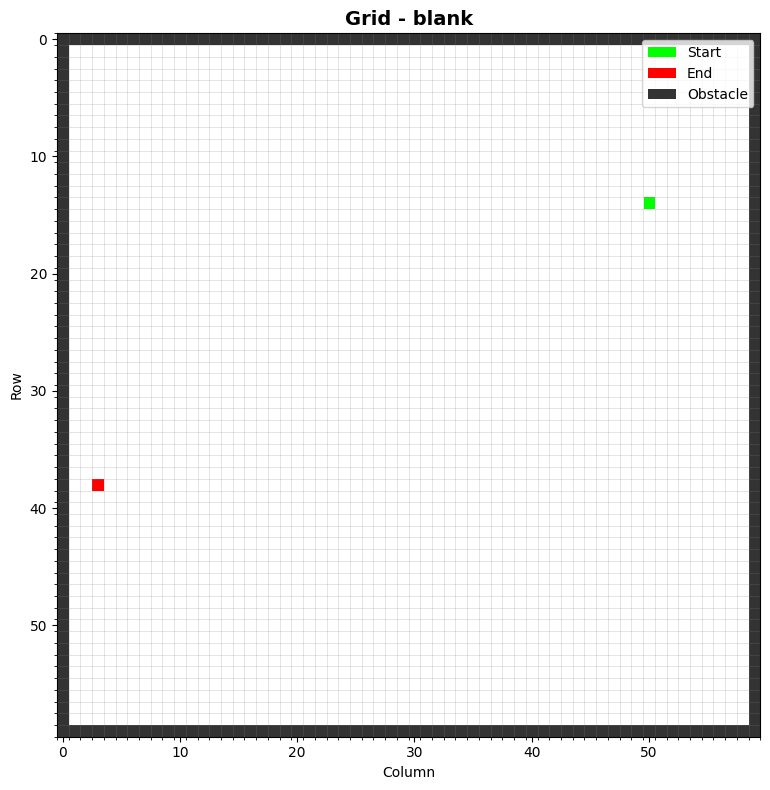

In [35]:
from pathlib import Path
import numpy as np

# Define project root (AI1_search-algorithms)
PROJECT_ROOT = Path.cwd().parents[1]

# Load blank test_0.txt
case_name = 'blank'
test_file = PROJECT_ROOT / "src" / "tests" / "SP" / case_name / "test_0.txt"

print(f"Loading {case_name} case...")
print(f"File path: {test_file}")

# Safety check
if not test_file.exists():
    raise FileNotFoundError(f"Test file not found: {test_file}")

problem = SPProblem(str(test_file))

print(f"✓ Grid: {problem.n} × {problem.m}")
print(f"  Obstacles: {np.sum(problem.grid == 1)}")

# Display grid
fig = display_grid(
    problem.grid,
    problem.start_node,
    problem.end_node,
    title=f"Grid - {case_name}"
)

# Save output
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

plt.savefig(OUTPUT_DIR / f"{case_name}_grid.png", dpi=150, bbox_inches="tight")
plt.show()

In [36]:
# Run algorithms
print(f"Running algorithms on {case_name}...")
experiment = GridExperiment(problem)

start_time = time.time()
trace = experiment.visualize(ALGORITHMS, trace_path=None)
elapsed = time.time() - start_time

print(f"✓ Completed in {elapsed:.2f}s\n")
print("Results:")
for algo_name in ALGORITHMS:
    if algo_name in trace['algorithms']:
        result = trace['algorithms'][algo_name]
        path_len = result.get('path_length', 'Failed')
        nodes_exp = result.get('nodes_expanded', 'N/A')
        time_t = result.get('execution_time_seconds', 'N/A')
        print(f"  {algo_name:20s} - Path: {path_len:4} | Nodes: {nodes_exp:6} | Time: {time_t:.4f}s")

Running algorithms on blank...
Running visual experiment on 60x60 grid...
Running DFS...
  ✓ DFS completed
Running BFS...
  ✓ BFS completed
Running UCS...
  ✓ UCS completed
Running GreedyBestFirst...
  ✓ GreedyBestFirst completed
Running AStarSearch...
  ✓ AStarSearch completed
✓ Completed in 0.32s

Results:
  DFS                  - Path: 2720 | Nodes:   2720 | Time: 0.1365s
  BFS                  - Path:   72 | Nodes:   3085 | Time: 0.0055s
  UCS                  - Path:   72 | Nodes:   3091 | Time: 0.1246s
  GreedyBestFirst      - Path:   72 | Nodes:     72 | Time: 0.0006s
  AStarSearch          - Path:   72 | Nodes:   1153 | Time: 0.0068s


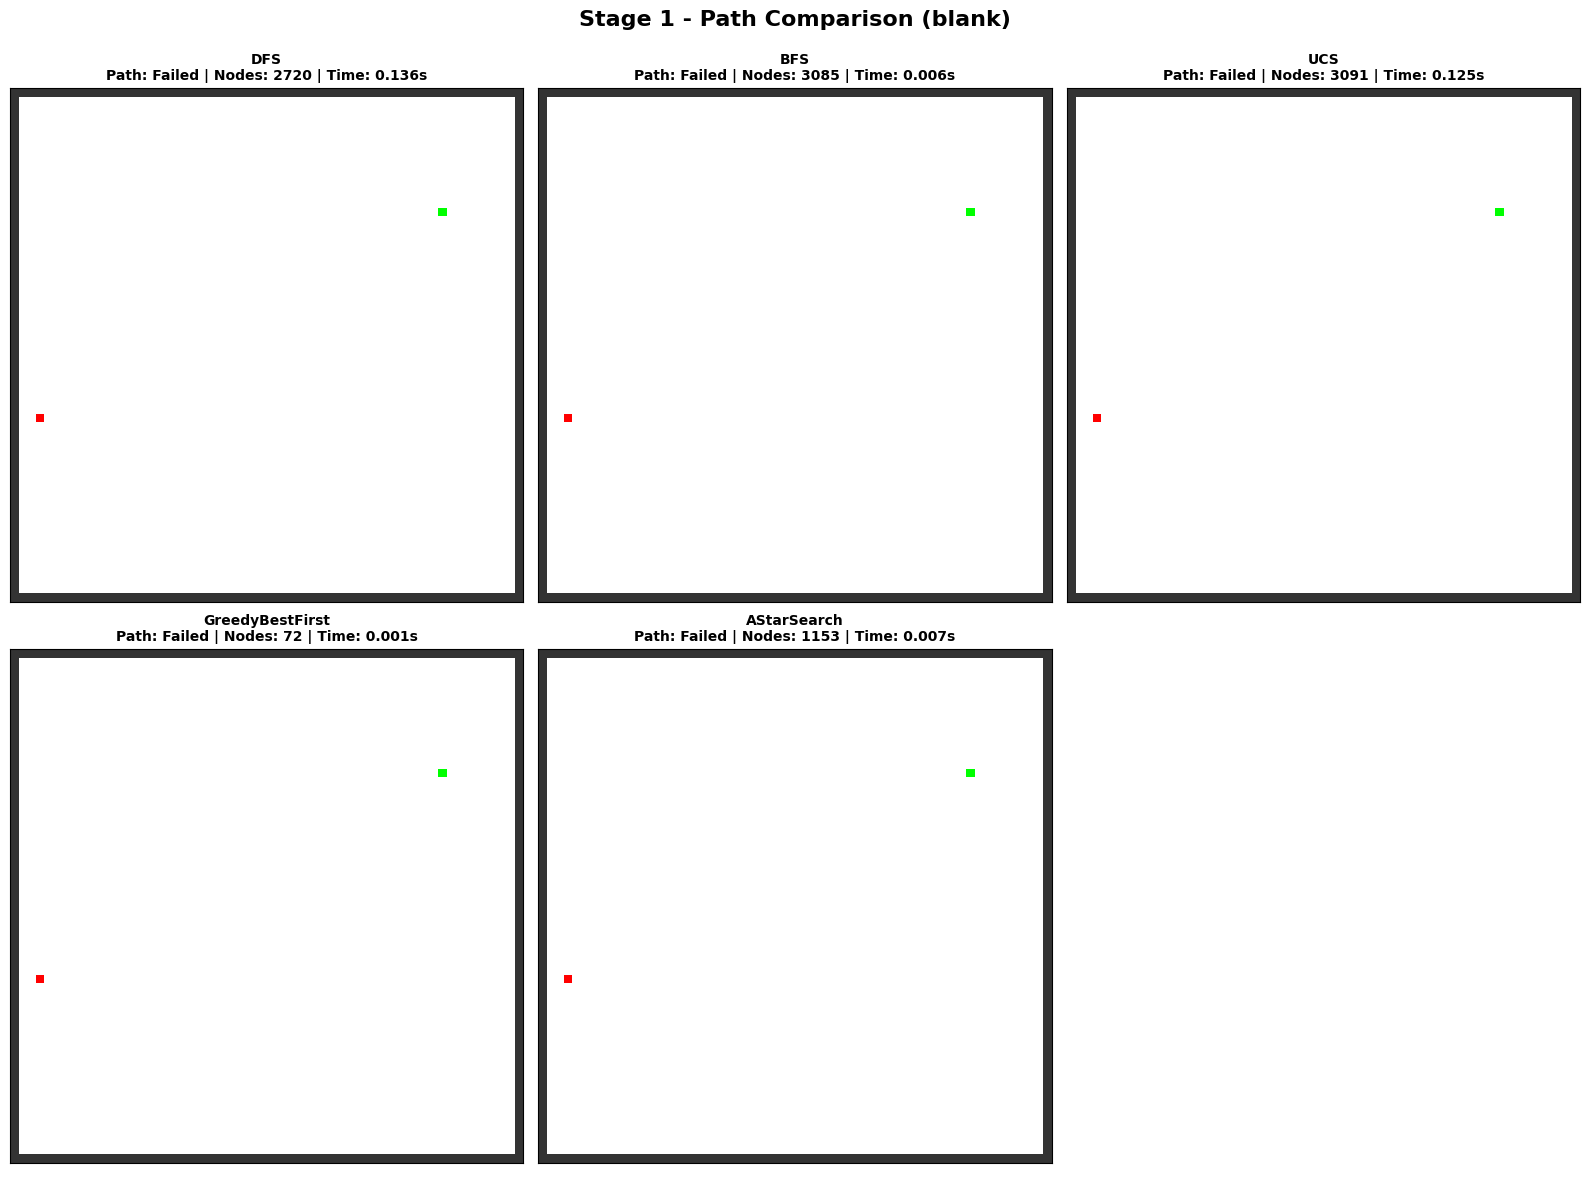

Saved trace to D:\Uni\IT\IntroToAI\AI1_search-algorithms\outputs\blank_stage1_trace.pkl


In [37]:
# Path comparison
fig = compare_paths(trace, ALGORITHMS, case_name)
plt.savefig(OUTPUT_DIR / f'{case_name}_paths.png', dpi=150, bbox_inches='tight')
plt.show()

# Save trace
trace_file = OUTPUT_DIR / f'{case_name}_stage1_trace.pkl'
with open(trace_file, 'wb') as f:
    pickle.dump(trace, f)
print(f"Saved trace to {trace_file}")

### maze_loops - Test Case 2

Loading maze_loops case...
File path: D:\Uni\IT\IntroToAI\AI1_search-algorithms\src\tests\SP\maze_loops\test_0.txt
✓ Grid: 61 × 61
  Obstacles: 1889


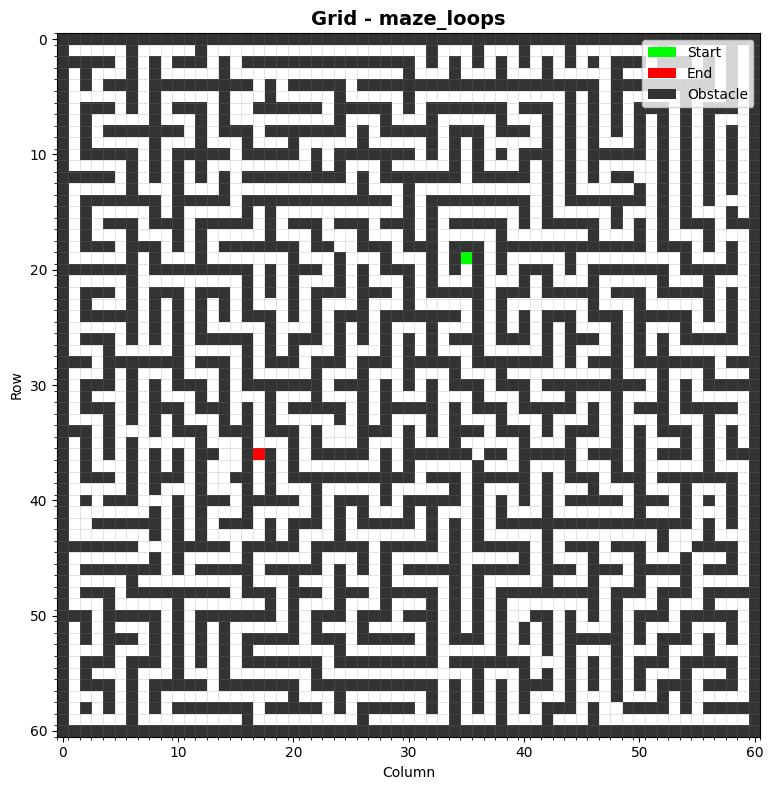

In [38]:
from pathlib import Path
import numpy as np

# Define project root (AI1_search-algorithms)
PROJECT_ROOT = Path.cwd().parents[1]

# Load maze_loops test_0.txt
case_name = 'maze_loops'
test_file = PROJECT_ROOT / "src" / "tests" / "SP" / case_name / "test_0.txt"

print(f"Loading {case_name} case...")
print(f"File path: {test_file}")

# Safety check
if not test_file.exists():
    raise FileNotFoundError(f"Test file not found: {test_file}")

problem = SPProblem(str(test_file))

print(f"✓ Grid: {problem.n} × {problem.m}")
print(f"  Obstacles: {np.sum(problem.grid == 1)}")

# Display grid
fig = display_grid(
    problem.grid,
    problem.start_node,
    problem.end_node,
    title=f"Grid - {case_name}"
)

# Ensure outputs directory exists
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

plt.savefig(OUTPUT_DIR / f"{case_name}_grid.png", dpi=150, bbox_inches="tight")
plt.show()

Running algorithms on maze_loops...
Running visual experiment on 61x61 grid...
Running DFS...
  ✓ DFS completed
Running BFS...
  ✓ BFS completed
Running UCS...
  ✓ UCS completed
Running GreedyBestFirst...
  ✓ GreedyBestFirst completed
Running AStarSearch...
  ✓ AStarSearch completed
Results:
  DFS                  - Path:  580 | Nodes:    884 | Time: 0.0038s
  BFS                  - Path:  200 | Nodes:    929 | Time: 0.0026s
  UCS                  - Path:  200 | Nodes:    942 | Time: 0.0031s
  GreedyBestFirst      - Path:  244 | Nodes:    483 | Time: 0.0018s
  AStarSearch          - Path:  200 | Nodes:    726 | Time: 0.0019s


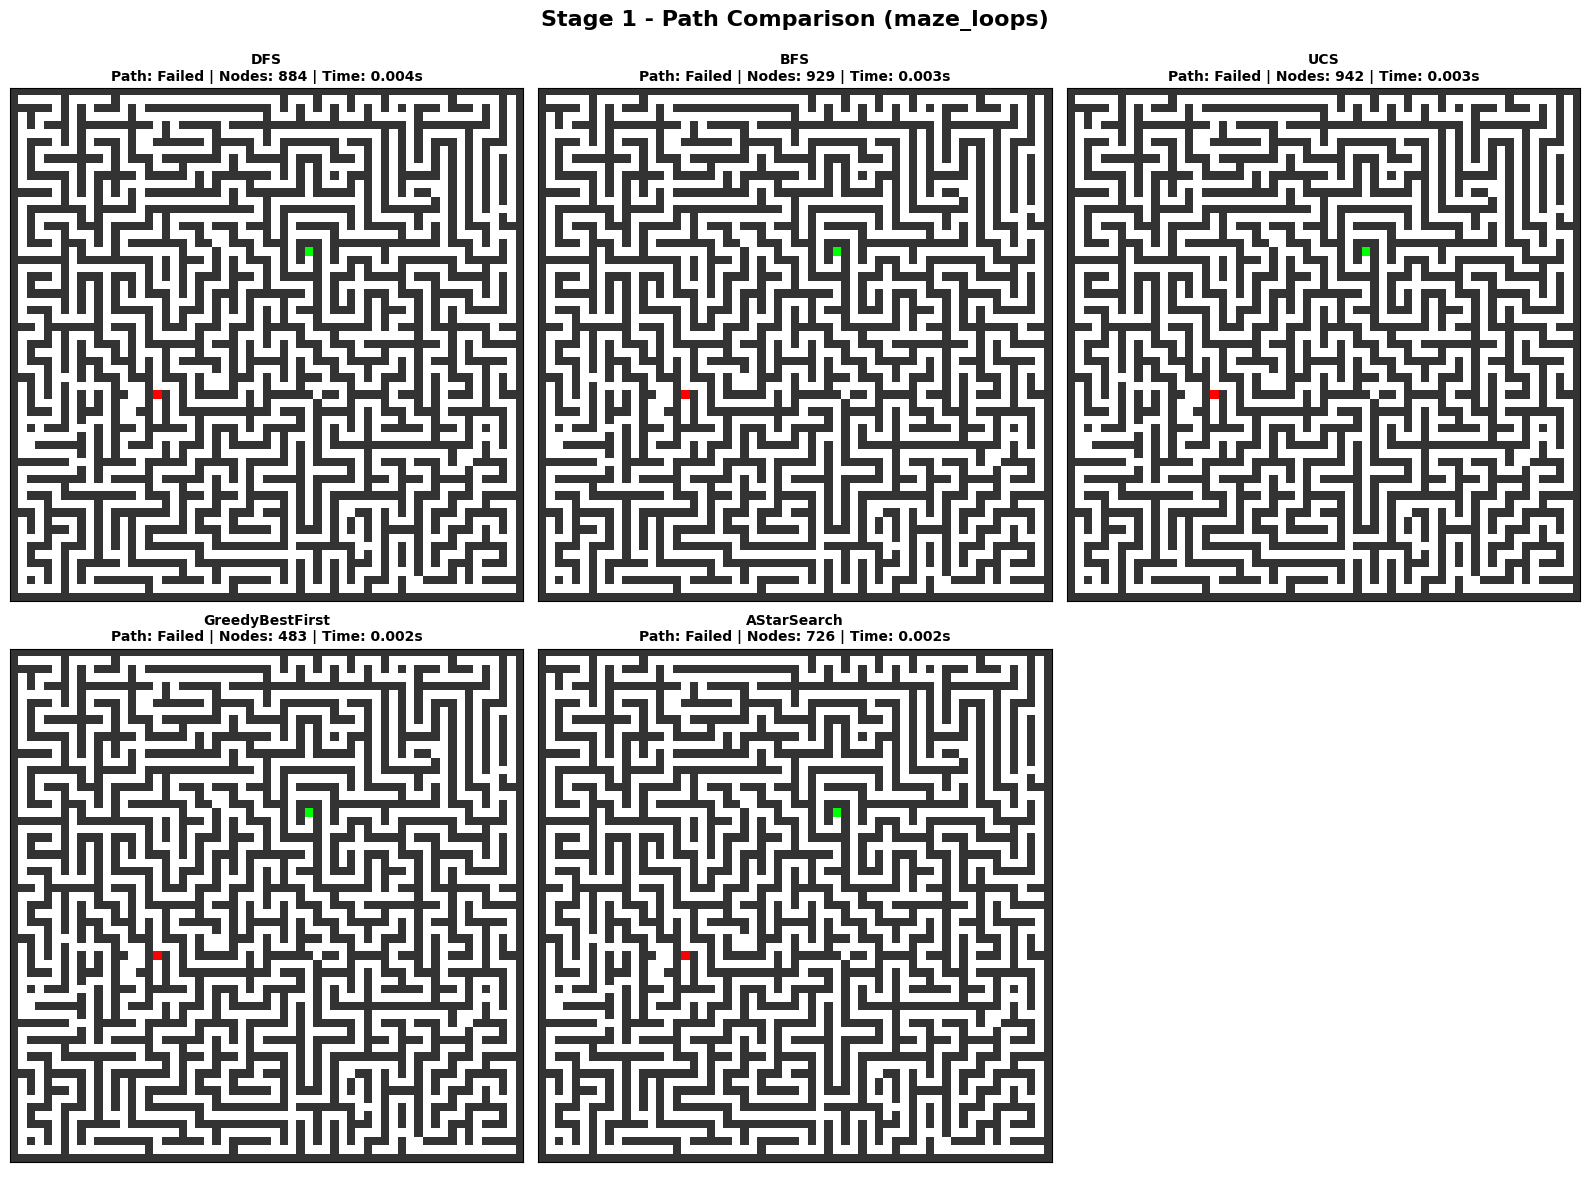

In [39]:
print(f"Running algorithms on {case_name}...")
experiment = GridExperiment(problem)
trace = experiment.visualize(ALGORITHMS, trace_path=None)

print(f"Results:")
for algo_name in ALGORITHMS:
    if algo_name in trace['algorithms']:
        result = trace['algorithms'][algo_name]
        path_len = result.get('path_length', 'Failed')
        nodes_exp = result.get('nodes_expanded', 'N/A')
        time_t = result.get('execution_time_seconds', 'N/A')
        print(f"  {algo_name:20s} - Path: {path_len:4} | Nodes: {nodes_exp:6} | Time: {time_t:.4f}s")

fig = compare_paths(trace, ALGORITHMS, case_name)
plt.savefig(OUTPUT_DIR / f'{case_name}_paths.png', dpi=150, bbox_inches='tight')
plt.show()

### obstacles - Test Case 3

Loading obstacles case...
File path: D:\Uni\IT\IntroToAI\AI1_search-algorithms\src\tests\SP\obstacles\test_0.txt
✓ Grid: 60 × 60
  Obstacles: 896


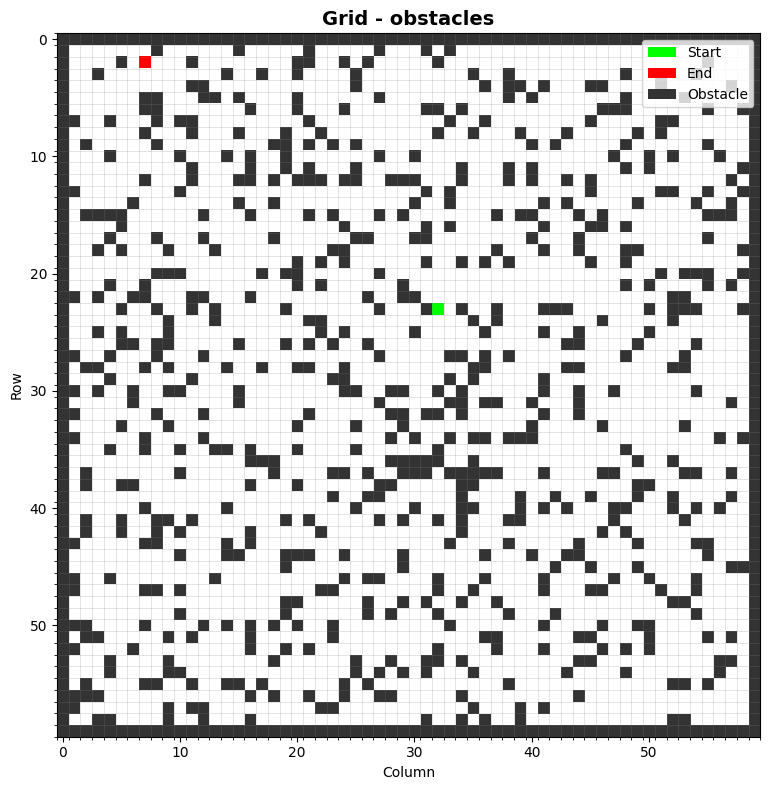

Running algorithms on obstacles...
Running visual experiment on 60x60 grid...
Running DFS...
  ✓ DFS completed
Running BFS...
  ✓ BFS completed
Running UCS...
  ✓ UCS completed
Running GreedyBestFirst...
  ✓ GreedyBestFirst completed
Running AStarSearch...
  ✓ AStarSearch completed
Results:
DFS                  - Path:  245 | Nodes:   2588 | Time: 0.0817s
BFS                  - Path:   47 | Nodes:   2231 | Time: 0.0039s
UCS                  - Path:   47 | Nodes:   2285 | Time: 0.0280s
GreedyBestFirst      - Path:   57 | Nodes:     63 | Time: 0.0002s
AStarSearch          - Path:   47 | Nodes:     82 | Time: 0.0003s


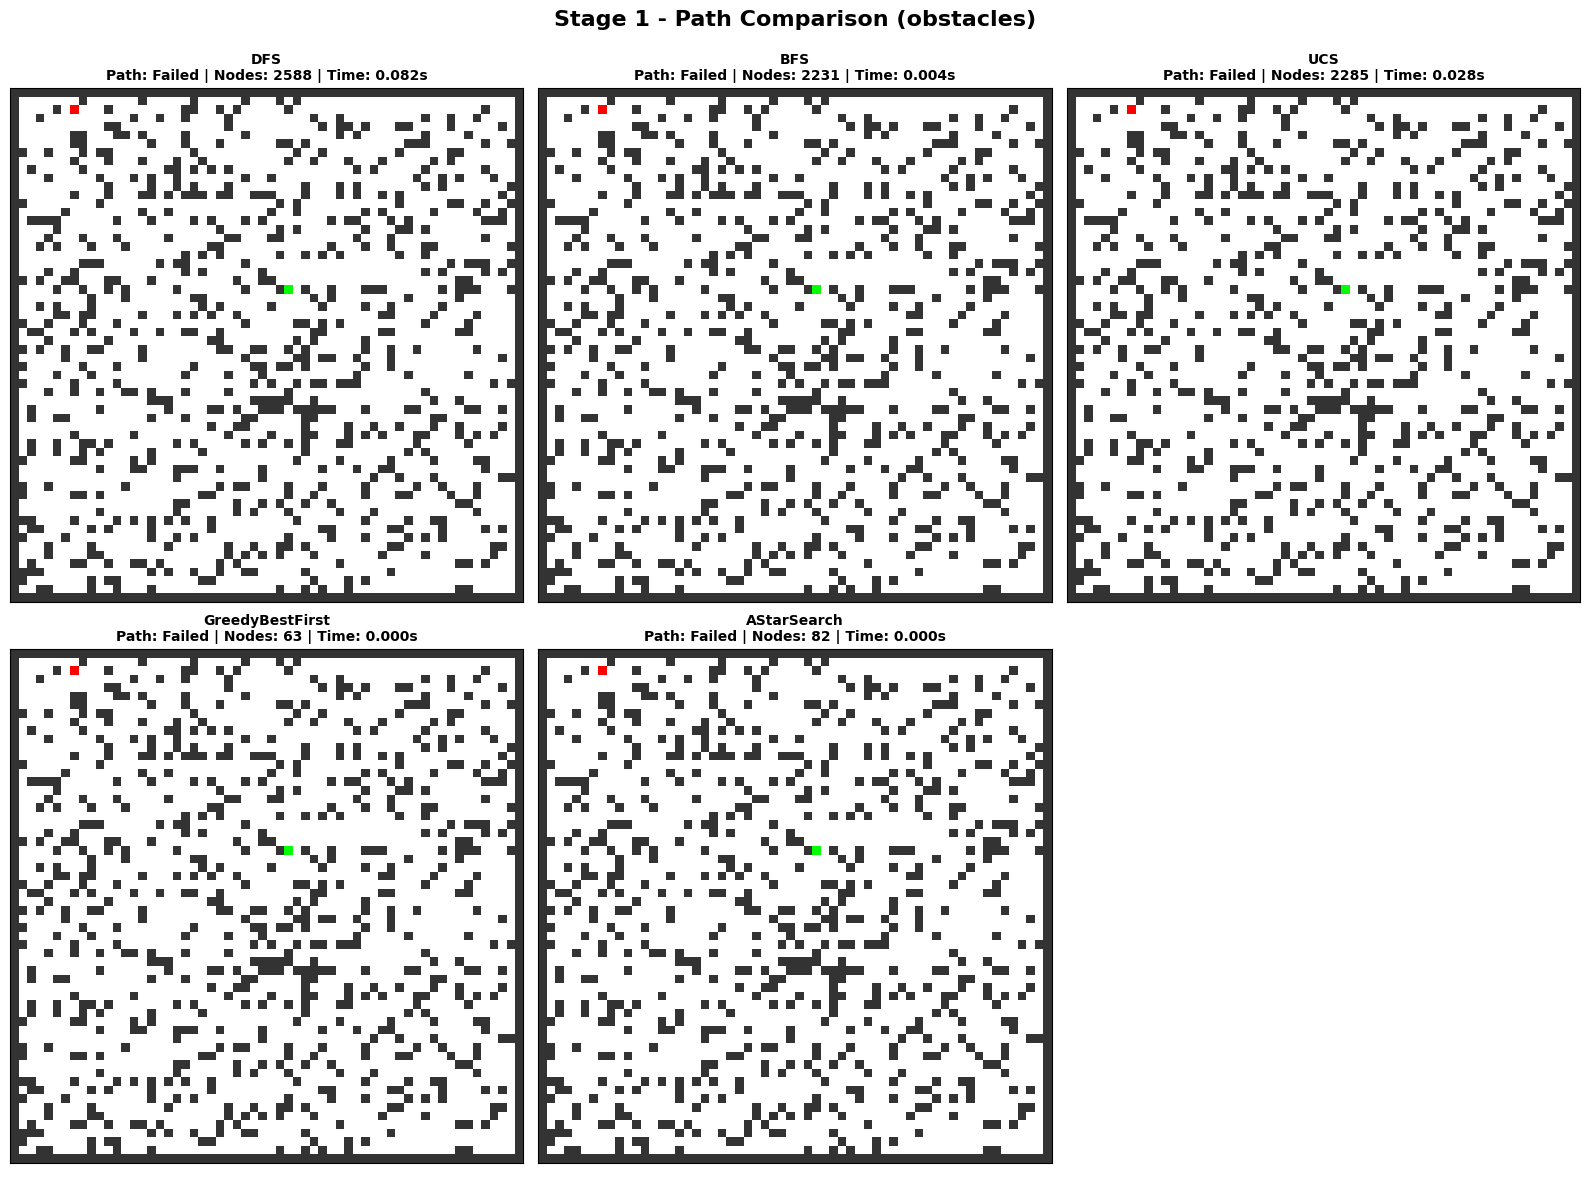

In [40]:
from pathlib import Path
import numpy as np

# Define project directories
PROJECT_ROOT = Path.cwd().parents[1]
TEST_DIR = PROJECT_ROOT / "src" / "tests" / "SP"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

# Load obstacles test
case_name = 'obstacles'
test_file = TEST_DIR / case_name / "test_0.txt"

print(f"Loading {case_name} case...")
print(f"File path: {test_file}")

if not test_file.exists():
    raise FileNotFoundError(f"Test file not found: {test_file}")

problem = SPProblem(str(test_file))

print(f"✓ Grid: {problem.n} × {problem.m}")
print(f"  Obstacles: {np.sum(problem.grid == 1)}")

# Display grid
fig = display_grid(
    problem.grid,
    problem.start_node,
    problem.end_node,
    title=f"Grid - {case_name}"
)

plt.savefig(OUTPUT_DIR / f"{case_name}_grid.png", dpi=150, bbox_inches="tight")
plt.show()

# Run algorithms
print(f"Running algorithms on {case_name}...")
experiment = GridExperiment(problem)
trace = experiment.visualize(ALGORITHMS, trace_path=None)

# Print results
print("Results:")
for algo_name in ALGORITHMS:
    if algo_name in trace['algorithms']:
        result = trace['algorithms'][algo_name]
        path_len = result.get('path_length', 'Failed')
        nodes_exp = result.get('nodes_expanded', 'N/A')
        time_t = result.get('execution_time_seconds', 0)

        print(f"{algo_name:20s} - Path: {path_len:4} | Nodes: {nodes_exp:6} | Time: {time_t:.4f}s")

# Compare paths
fig = compare_paths(trace, ALGORITHMS, case_name)

plt.savefig(OUTPUT_DIR / f"{case_name}_paths.png", dpi=150, bbox_inches="tight")
plt.show()

### dense - Test Case 4

Loading obstacles_dense case...
File path: D:\Uni\IT\IntroToAI\AI1_search-algorithms\src\tests\SP\obstacles_dense\test_0.txt
✓ Grid: 60 × 60
  Obstacles: 1428


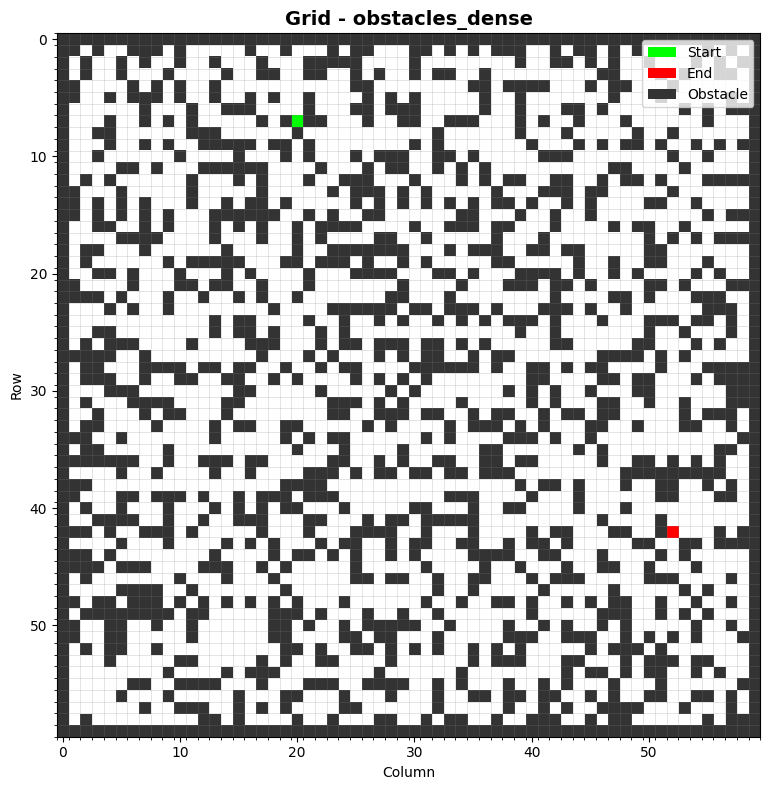

Running algorithms on obstacles_dense...
Running visual experiment on 60x60 grid...
Running DFS...
  ✓ DFS completed
Running BFS...
  ✓ BFS completed
Running UCS...
  ✓ UCS completed
Running GreedyBestFirst...
  ✓ GreedyBestFirst completed
Running AStarSearch...
  ✓ AStarSearch completed
Results:
DFS                  - Path:  238 | Nodes:   1559 | Time: 0.0239s
BFS                  - Path:   84 | Nodes:   1649 | Time: 0.0035s
UCS                  - Path:   84 | Nodes:   1657 | Time: 0.0076s
GreedyBestFirst      - Path:  136 | Nodes:    380 | Time: 0.0014s
AStarSearch          - Path:   84 | Nodes:    481 | Time: 0.0012s


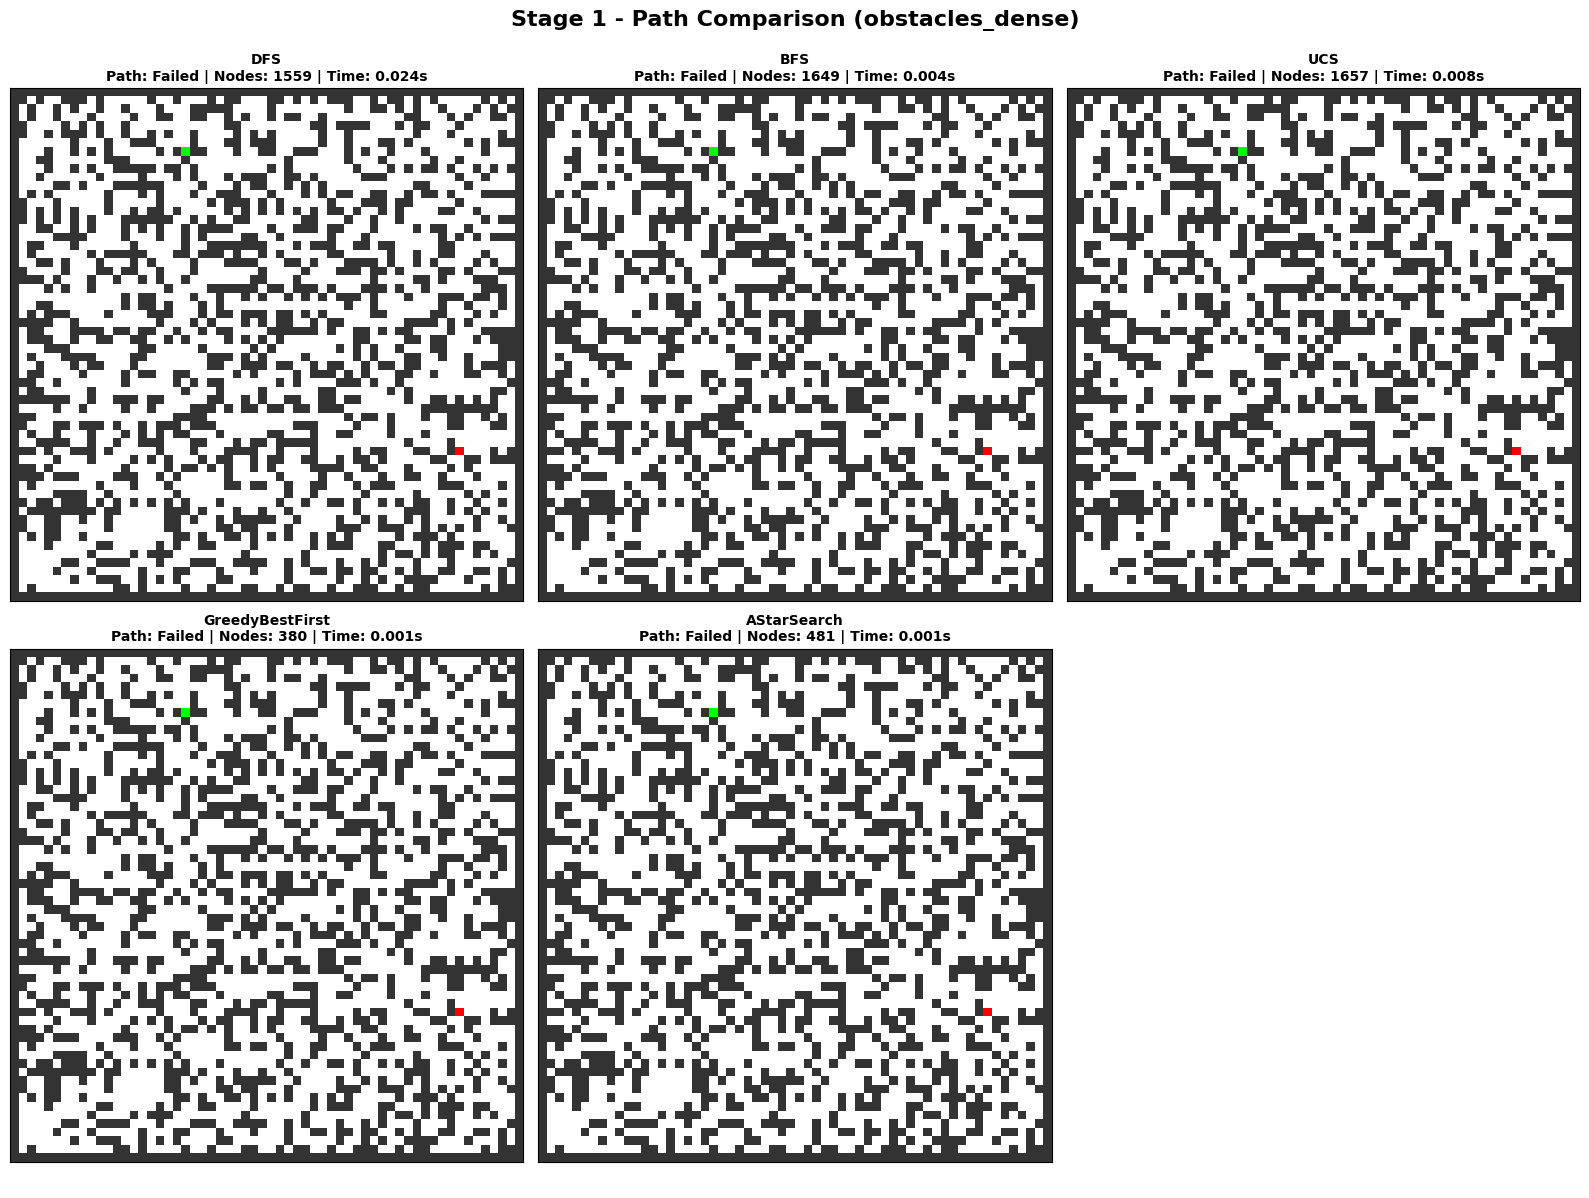

In [42]:
from pathlib import Path
import numpy as np

# Define project directories
PROJECT_ROOT = Path.cwd().parents[1]
TEST_DIR = PROJECT_ROOT / "src" / "tests" / "SP"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

# Load dense test
case_name = 'obstacles_dense'
test_file = TEST_DIR / case_name / "test_0.txt"

print(f"Loading {case_name} case...")
print(f"File path: {test_file}")

if not test_file.exists():
    raise FileNotFoundError(f"Test file not found: {test_file}")

problem = SPProblem(str(test_file))

print(f"✓ Grid: {problem.n} × {problem.m}")
print(f"  Obstacles: {np.sum(problem.grid == 1)}")

# Display grid
fig = display_grid(
    problem.grid,
    problem.start_node,
    problem.end_node,
    title=f"Grid - {case_name}"
)

plt.savefig(OUTPUT_DIR / f"{case_name}_grid.png", dpi=150, bbox_inches="tight")
plt.show()

# Run algorithms
print(f"Running algorithms on {case_name}...")
experiment = GridExperiment(problem)
trace = experiment.visualize(ALGORITHMS, trace_path=None)

# Print results
print("Results:")
for algo_name in ALGORITHMS:
    if algo_name in trace['algorithms']:
        result = trace['algorithms'][algo_name]

        path_len = result.get('path_length', 'Failed')
        nodes_exp = result.get('nodes_expanded', 'N/A')
        time_t = result.get('execution_time_seconds', 0)

        print(f"{algo_name:20s} - Path: {path_len:4} | Nodes: {nodes_exp:6} | Time: {time_t:.4f}s")

# Compare paths
fig = compare_paths(trace, ALGORITHMS, case_name)

plt.savefig(OUTPUT_DIR / f"{case_name}_paths.png", dpi=150, bbox_inches="tight")
plt.show()

### perfect_maze - Test Case 5

Loading perfect_maze case...
File path: D:\Uni\IT\IntroToAI\AI1_search-algorithms\src\tests\SP\perfect_maze\test_0.txt
✓ Grid: 61 × 61
  Obstacles: 1922


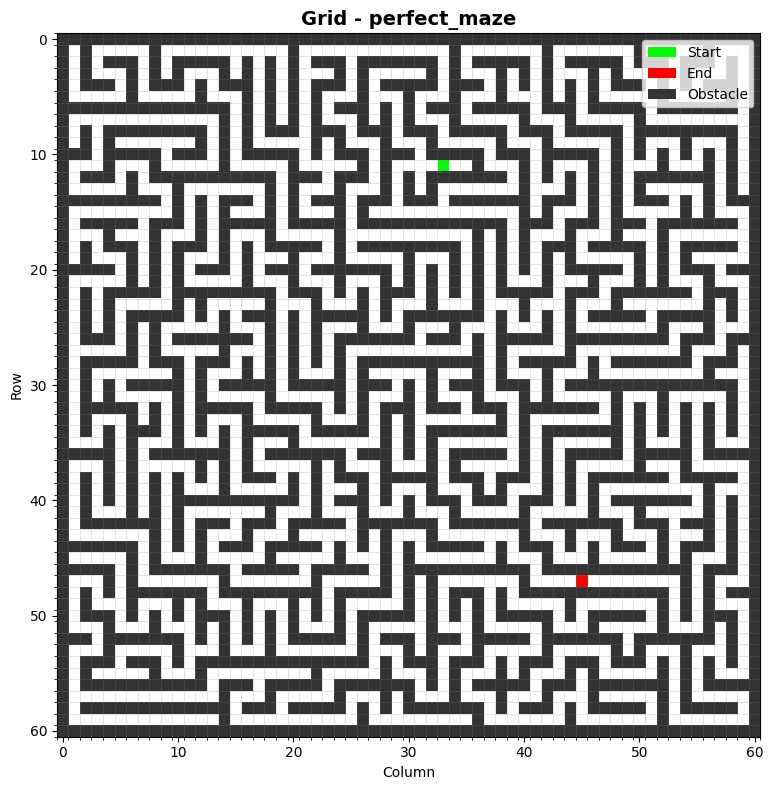

Running algorithms on perfect_maze...
Running visual experiment on 61x61 grid...
Running DFS...
  ✓ DFS completed
Running BFS...
  ✓ BFS completed
Running UCS...
  ✓ UCS completed
Running GreedyBestFirst...
  ✓ GreedyBestFirst completed
Running AStarSearch...
  ✓ AStarSearch completed
Results:
DFS                  - Path:  437 | Nodes:   1249 | Time: 0.0085s
BFS                  - Path:  437 | Nodes:   1029 | Time: 0.0033s
UCS                  - Path:  437 | Nodes:   1031 | Time: 0.0070s
GreedyBestFirst      - Path:  437 | Nodes:    827 | Time: 0.0023s
AStarSearch          - Path:  437 | Nodes:    979 | Time: 0.0045s


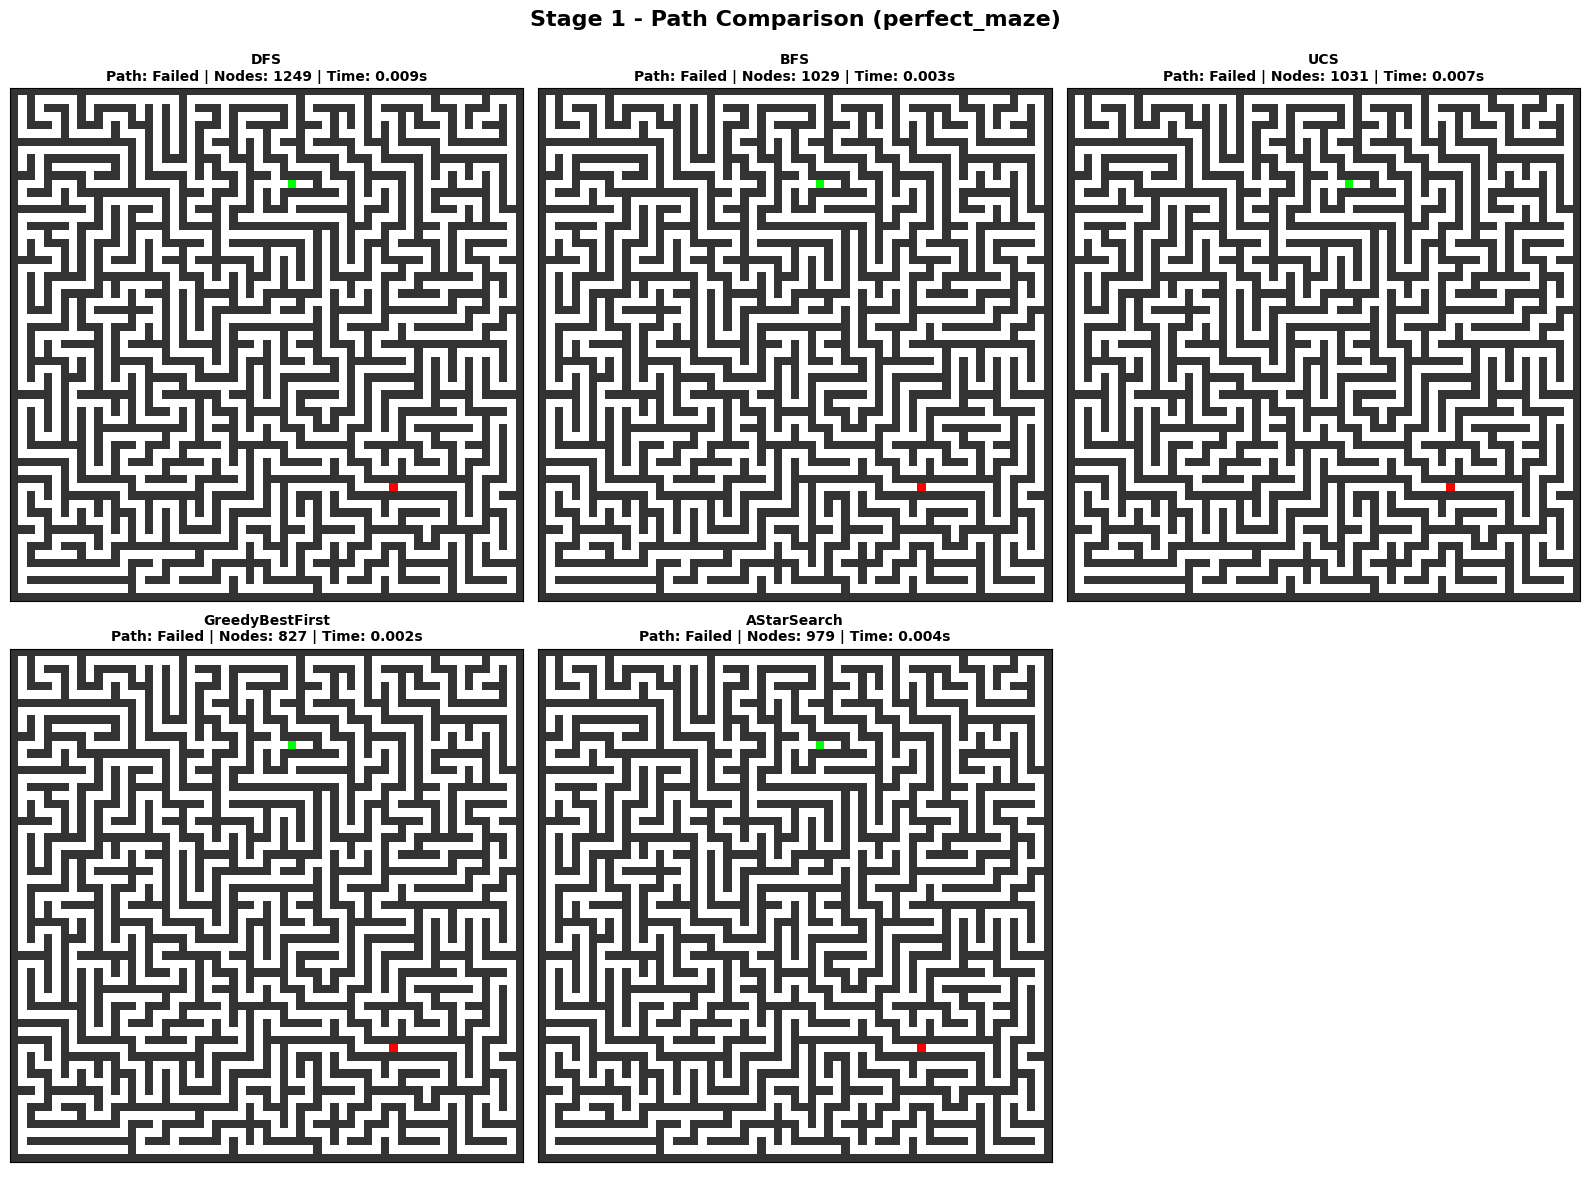

In [43]:
from pathlib import Path
import numpy as np

# Define project directories
PROJECT_ROOT = Path.cwd().parents[1]
TEST_DIR = PROJECT_ROOT / "src" / "tests" / "SP"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

# Load perfect_maze test
case_name = 'perfect_maze'
test_file = TEST_DIR / case_name / "test_0.txt"

print(f"Loading {case_name} case...")
print(f"File path: {test_file}")

if not test_file.exists():
    raise FileNotFoundError(f"Test file not found: {test_file}")

problem = SPProblem(str(test_file))

print(f"✓ Grid: {problem.n} × {problem.m}")
print(f"  Obstacles: {np.sum(problem.grid == 1)}")

# Display grid
fig = display_grid(
    problem.grid,
    problem.start_node,
    problem.end_node,
    title=f"Grid - {case_name}"
)

plt.savefig(OUTPUT_DIR / f"{case_name}_grid.png", dpi=150, bbox_inches="tight")
plt.show()

# Run algorithms
print(f"Running algorithms on {case_name}...")
experiment = GridExperiment(problem)
trace = experiment.visualize(ALGORITHMS, trace_path=None)

# Print results
print("Results:")
for algo_name in ALGORITHMS:
    if algo_name in trace['algorithms']:
        result = trace['algorithms'][algo_name]

        path_len = result.get('path_length', 'Failed')
        nodes_exp = result.get('nodes_expanded', 'N/A')
        time_t = result.get('execution_time_seconds', 0)

        print(f"{algo_name:20s} - Path: {path_len:4} | Nodes: {nodes_exp:6} | Time: {time_t:.4f}s")

# Compare paths
fig = compare_paths(trace, ALGORITHMS, case_name)

plt.savefig(OUTPUT_DIR / f"{case_name}_paths.png", dpi=150, bbox_inches="tight")
plt.show()

## Stage 2: Benchmark Analysis

### Instructions for Pre-Running Benchmarks

Before running Stage 2, you need to generate benchmark results for test_1.txt through test_N.txt.

**Option 1: Run Pre-Generated Scripts**
```bash
python outputs/grid_analysis/prerun_blank_benchmark.py
python outputs/grid_analysis/prerun_maze_loops_benchmark.py
python outputs/grid_analysis/prerun_obstacles_benchmark.py
python outputs/grid_analysis/prerun_dense_benchmark.py
python outputs/grid_analysis/prerun_perfect_maze_benchmark.py
```

**Option 2: Use the Standalone Python Script**
```bash
python grid_pathfinding_analysis.py
```


In [58]:
# Benchmark analysis functions

def analyze_path_length(df, case_name):
    """Analyze path length performance - % difference from best."""
    fig, ax = plt.subplots(figsize=(12, 6))
    
    grouped = df.groupby('algorithm')['best_fitness'].agg(['mean', 'std']).reset_index()
    best_path = grouped['mean'].min()
    grouped['pct_diff'] = ((grouped['mean'] - best_path) / best_path * 100).round(2)
    grouped = grouped.sort_values('pct_diff')
    
    colors = sns.color_palette("husl", len(grouped))
    bars = ax.barh(range(len(grouped)), grouped['pct_diff'], color=colors, alpha=0.8, edgecolor='black')
    
    for i, (idx, row) in enumerate(grouped.iterrows()):
        ax.text(row['pct_diff'] + 0.5, i, f"{row['pct_diff']:.1f}%", va='center', fontsize=10)
    
    ax.set_yticks(range(len(grouped)))
    ax.set_yticklabels(grouped['algorithm'])
    ax.set_xlabel('% Difference from Best Solution', fontsize=11, fontweight='bold')
    ax.set_title(f'Path Length Performance - {case_name}', fontsize=13, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    return fig


def analyze_execution_time(df, case_name):
    """Analyze execution time across algorithms."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    time_stats = df.groupby('algorithm')['execution_time_seconds'].agg(['mean', 'std']).reset_index()
    time_stats = time_stats.sort_values('mean')
    
    colors = sns.color_palette("husl", len(time_stats))
    bars = axes[0].barh(range(len(time_stats)), time_stats['mean'], color=colors, alpha=0.8, edgecolor='black')
    axes[0].errorbar(time_stats['mean'], range(len(time_stats)), 
                     xerr=time_stats['std'], fmt='none', color='black', elinewidth=1, capsize=3)
    
    axes[0].set_yticks(range(len(time_stats)))
    axes[0].set_yticklabels(time_stats['algorithm'])
    axes[0].set_xlabel('Execution Time (seconds)', fontsize=11, fontweight='bold')
    axes[0].set_title('Mean Execution Time', fontsize=12, fontweight='bold')
    axes[0].set_xscale('log')
    axes[0].grid(axis='x', alpha=0.3)
    
    for algo in df['algorithm'].unique():
        algo_data = df[df['algorithm'] == algo]['execution_time_seconds']
        axes[1].hist(algo_data, bins=10, alpha=0.6, label=algo)
    
    axes[1].set_xlabel('Execution Time (seconds)', fontsize=11, fontweight='bold')
    axes[1].set_ylabel('Frequency', fontsize=11, fontweight='bold')
    axes[1].set_title('Distribution of Execution Times', fontsize=12, fontweight='bold')
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    
    fig.suptitle(f'Execution Time Analysis - {case_name}', fontsize=13, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    return fig


def analyze_nodes_expanded(df, case_name):
    """Analyze nodes expanded across algorithms."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    nodes_stats = df.groupby('algorithm')['nodes_expanded'].agg(['mean', 'std']).reset_index()
    nodes_stats = nodes_stats.sort_values('mean', ascending=False)
    
    colors = sns.color_palette("husl", len(nodes_stats))
    bars = axes[0].barh(range(len(nodes_stats)), nodes_stats['mean'], color=colors, alpha=0.8, edgecolor='black')
    axes[0].errorbar(nodes_stats['mean'], range(len(nodes_stats)), 
                     xerr=nodes_stats['std'], fmt='none', color='black', elinewidth=1, capsize=3)
    
    axes[0].set_yticks(range(len(nodes_stats)))
    axes[0].set_yticklabels(nodes_stats['algorithm'])
    axes[0].set_xlabel('Nodes Expanded', fontsize=11, fontweight='bold')
    axes[0].set_title('Mean Nodes Expanded', fontsize=12, fontweight='bold')
    axes[0].grid(axis='x', alpha=0.3)
    
    plot_data = [df[df['algorithm'] == algo]['nodes_expanded'].values for algo in df['algorithm'].unique()]
    bp = axes[1].boxplot(plot_data, labels=df['algorithm'].unique(), vert=True, patch_artist=True)
    
    for patch, color in zip(bp['boxes'], sns.color_palette("husl", len(plot_data))):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)
    
    axes[1].set_ylabel('Nodes Expanded', fontsize=11, fontweight='bold')
    axes[1].set_title('Distribution of Nodes Expanded', fontsize=12, fontweight='bold')
    axes[1].grid(alpha=0.3, axis='y')
    
    fig.suptitle(f'Nodes Expanded Analysis - {case_name}', fontsize=13, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    return fig


def print_summary_stats(df, case_name):
    """Print summary statistics table."""
    summary = df.groupby('algorithm').agg({
        'best_fitness': ['mean', 'std', 'min', 'max'],
        'nodes_expanded': ['mean', 'std'],
        'execution_time_seconds': ['mean', 'std']
    }).round(4)
    
    print(f"\n{case_name.upper()} Summary Statistics:")
    print(summary)

print("✓ Benchmark analysis functions loaded")

✓ Benchmark analysis functions loaded


In [59]:
from pathlib import Path

# locate project root
PROJECT_ROOT = Path.cwd().parents[1]

# correct output folder
OUTPUT_DIR = PROJECT_ROOT / "src" / "outputs" / "grid_analysis"

print("Output directory:", OUTPUT_DIR)

Output directory: D:\Uni\IT\IntroToAI\AI1_search-algorithms\src\outputs\grid_analysis


In [60]:
# Load and display benchmark results for each case
benchmark_results = {}

for case_name in TEST_CASES.keys():

    csv_path = OUTPUT_DIR / f"{case_name}_benchmark.csv"

    if csv_path.exists():
        df = pd.read_csv(csv_path)
        benchmark_results[case_name] = df
        print(f"✓ Loaded {case_name}: {len(df)} results")

    else:
        print(f"✗ Benchmark CSV not found: {csv_path}")
        print(f"  Please run: python {OUTPUT_DIR}/prerun_{case_name}_benchmark.py")

✓ Loaded blank: 50 results
✓ Loaded maze_loops: 100 results
✓ Loaded obstacles: 100 results
✓ Loaded obstacles_dense: 100 results
✓ Loaded perfect_maze: 100 results


### blank - Benchmark Results

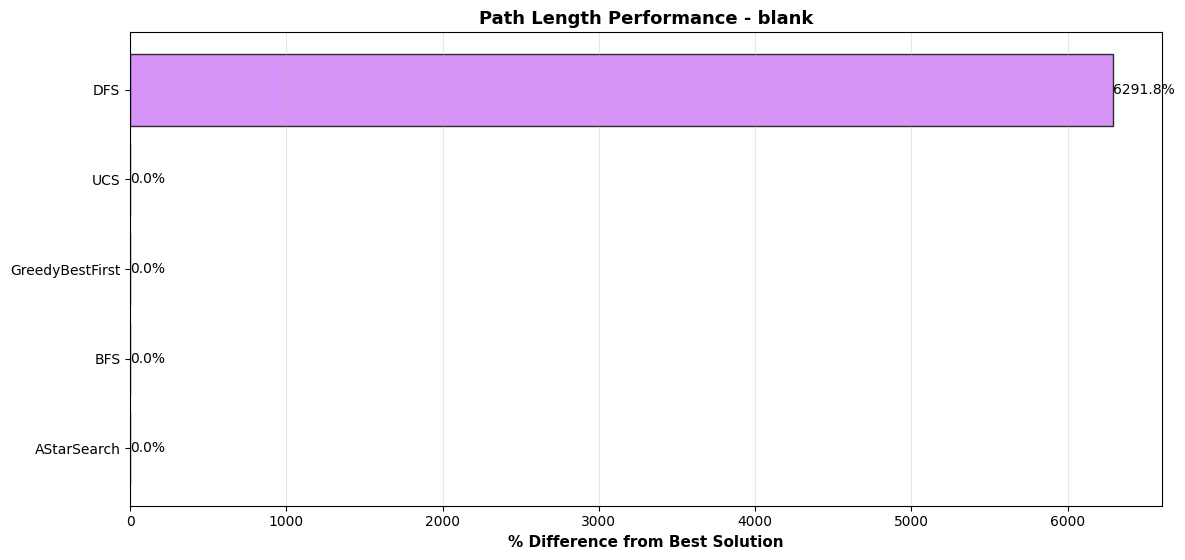

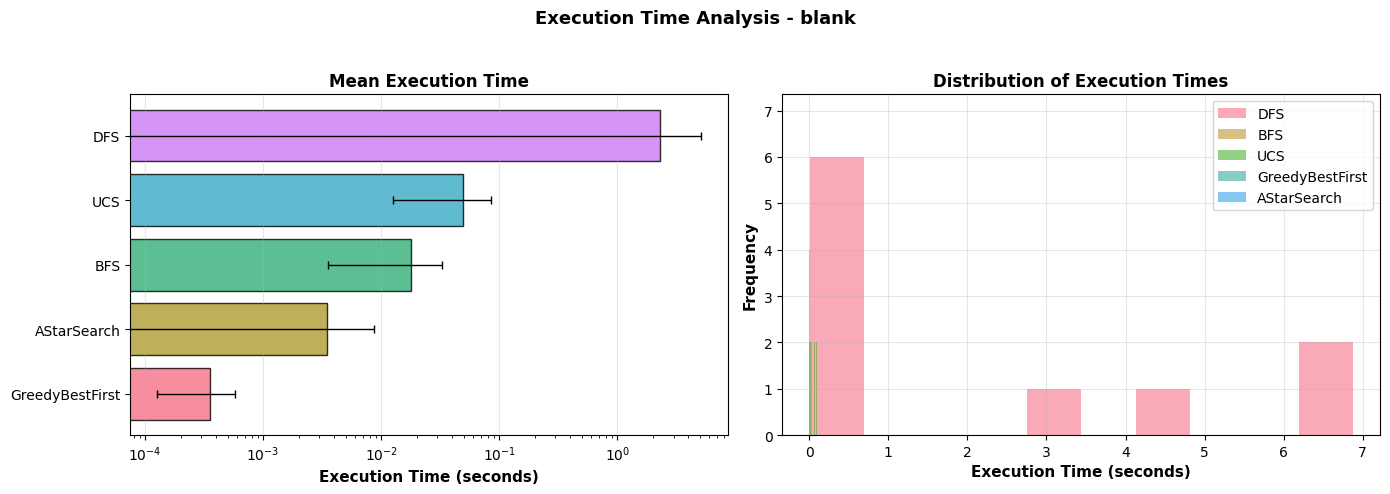

C:\Users\Thong\AppData\Local\Temp\ipykernel_22072\3205350605.py:81: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(plot_data, labels=df['algorithm'].unique(), vert=True, patch_artist=True)


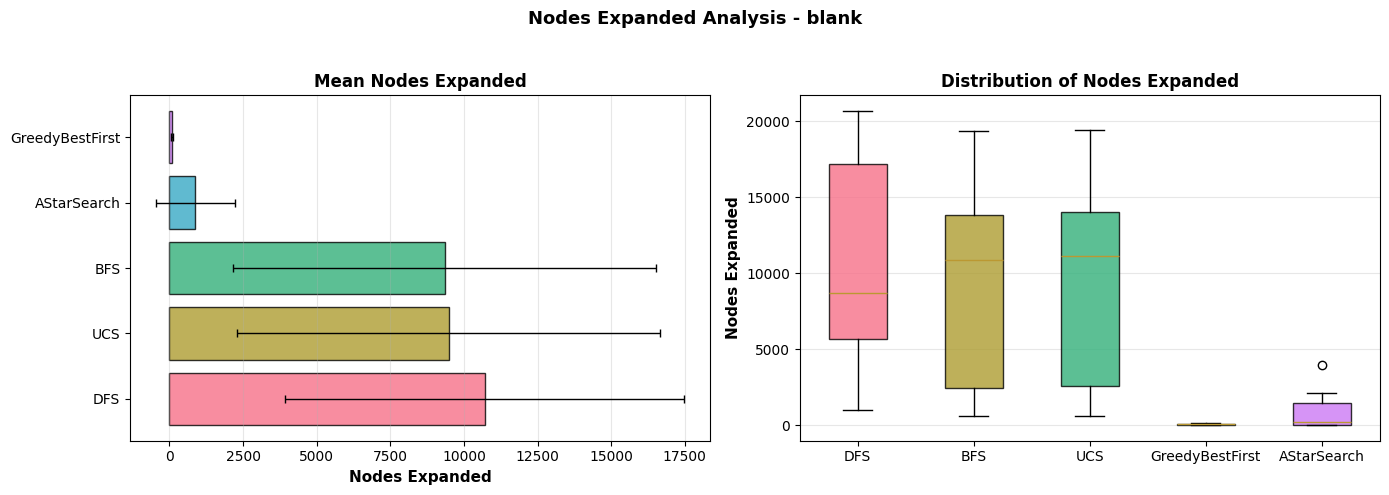


BLANK Summary Statistics:
                best_fitness                            nodes_expanded  \
                        mean        std    min      max           mean   
algorithm                                                                
AStarSearch             80.6    44.5376   21.0    134.0          885.2   
BFS                     80.6    44.5376   21.0    134.0         9342.1   
DFS                   5151.8  4429.1610  486.0  14626.0        10707.9   
GreedyBestFirst         80.6    44.5376   21.0    134.0           81.6   
UCS                     80.6    44.5376   21.0    134.0         9483.1   

                           execution_time_seconds          
                       std                   mean     std  
algorithm                                                  
AStarSearch      1324.9417                 0.0035  0.0052  
BFS              7172.5544                 0.0180  0.0145  
DFS              6768.5177                 2.3070  2.7975  
GreedyBestFirst    4

In [61]:
case_name = 'blank'
if case_name in benchmark_results:
    df = benchmark_results[case_name]
    
    fig = analyze_path_length(df, case_name)
    plt.savefig(OUTPUT_DIR / f'{case_name}_pathlen_performance.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    fig = analyze_execution_time(df, case_name)
    plt.savefig(OUTPUT_DIR / f'{case_name}_execution_time.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    fig = analyze_nodes_expanded(df, case_name)
    plt.savefig(OUTPUT_DIR / f'{case_name}_nodes_expanded.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print_summary_stats(df, case_name)
else:
    print(f"Benchmark data not available for {case_name}")

### maze_loops - Benchmark Results

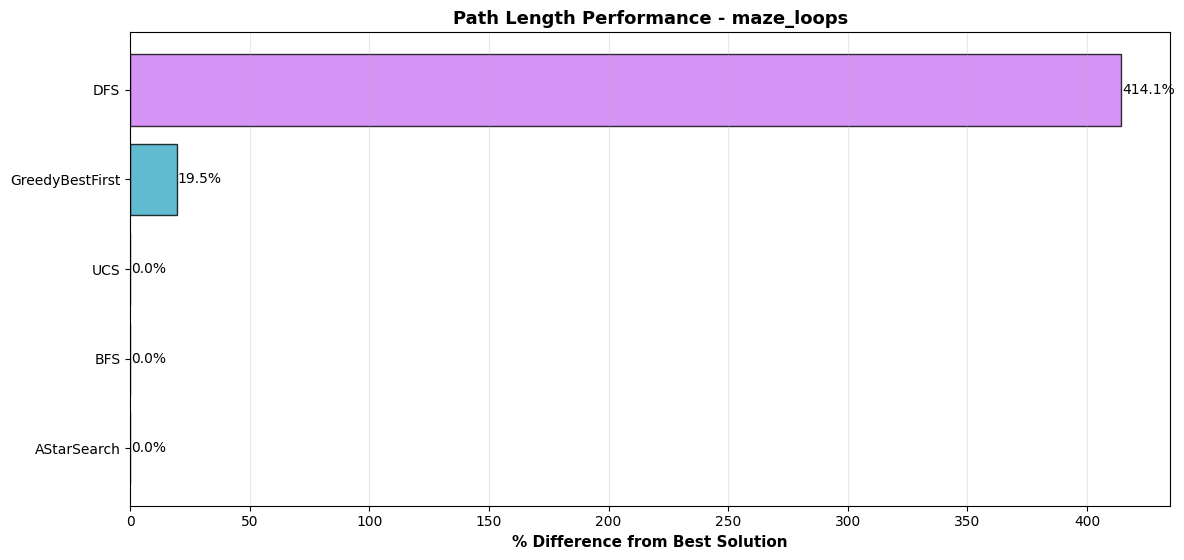

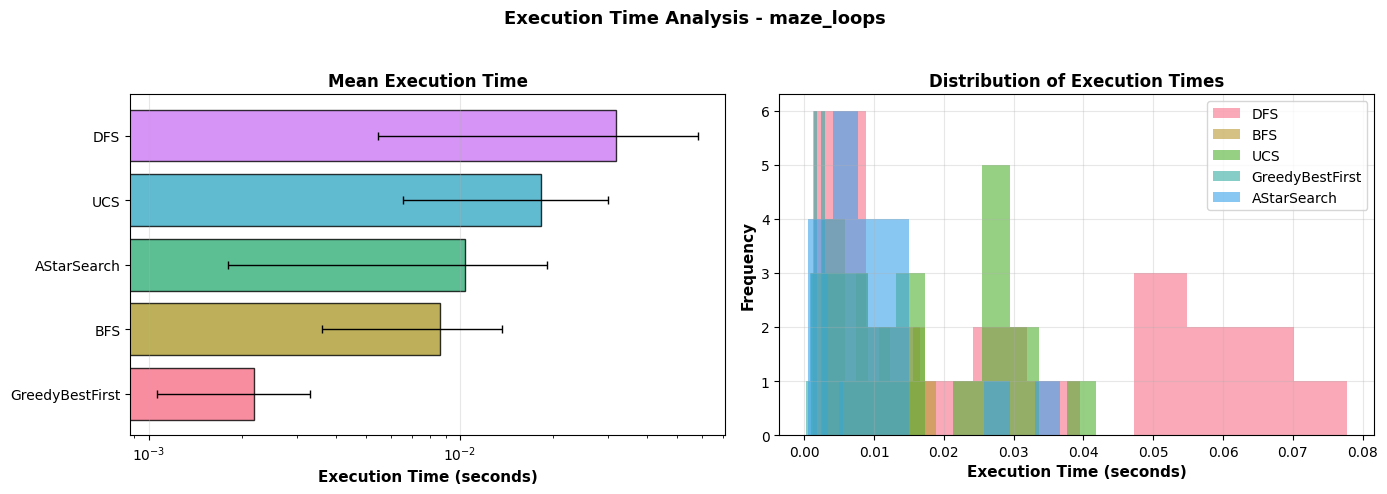

C:\Users\Thong\AppData\Local\Temp\ipykernel_22072\3205350605.py:81: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(plot_data, labels=df['algorithm'].unique(), vert=True, patch_artist=True)


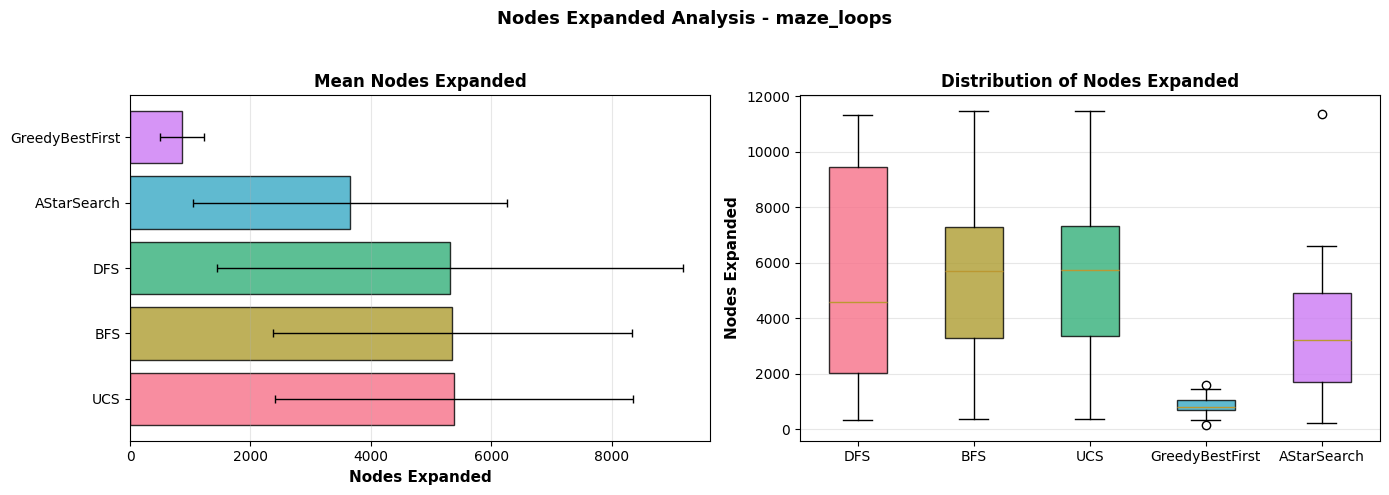


MAZE_LOOPS Summary Statistics:
                best_fitness                          nodes_expanded  \
                        mean       std    min     max           mean   
algorithm                                                              
AStarSearch            323.4  134.1054   84.0   576.0        3647.20   
BFS                    323.4  134.1054   84.0   576.0        5354.90   
DFS                   1662.7  921.1119  300.0  3184.0        5317.00   
GreedyBestFirst        386.4  194.8928   84.0   817.0         866.40   
UCS                    323.4  134.1054   84.0   576.0        5381.85   

                           execution_time_seconds          
                       std                   mean     std  
algorithm                                                  
AStarSearch      2607.2272                 0.0104  0.0086  
BFS              2979.4095                 0.0086  0.0050  
DFS              3867.1665                 0.0319  0.0264  
GreedyBestFirst   368.7824     

In [62]:
case_name = 'maze_loops'
if case_name in benchmark_results:
    df = benchmark_results[case_name]
    
    fig = analyze_path_length(df, case_name)
    plt.savefig(OUTPUT_DIR / f'{case_name}_pathlen_performance.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    fig = analyze_execution_time(df, case_name)
    plt.savefig(OUTPUT_DIR / f'{case_name}_execution_time.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    fig = analyze_nodes_expanded(df, case_name)
    plt.savefig(OUTPUT_DIR / f'{case_name}_nodes_expanded.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print_summary_stats(df, case_name)
else:
    print(f"Benchmark data not available for {case_name}")

### obstacles - Benchmark Results

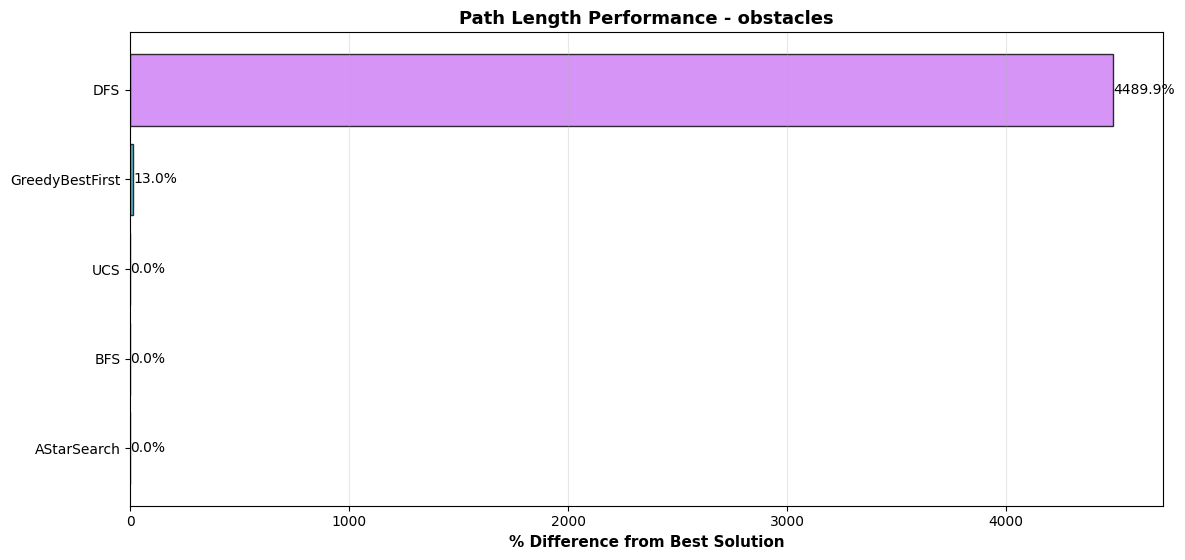

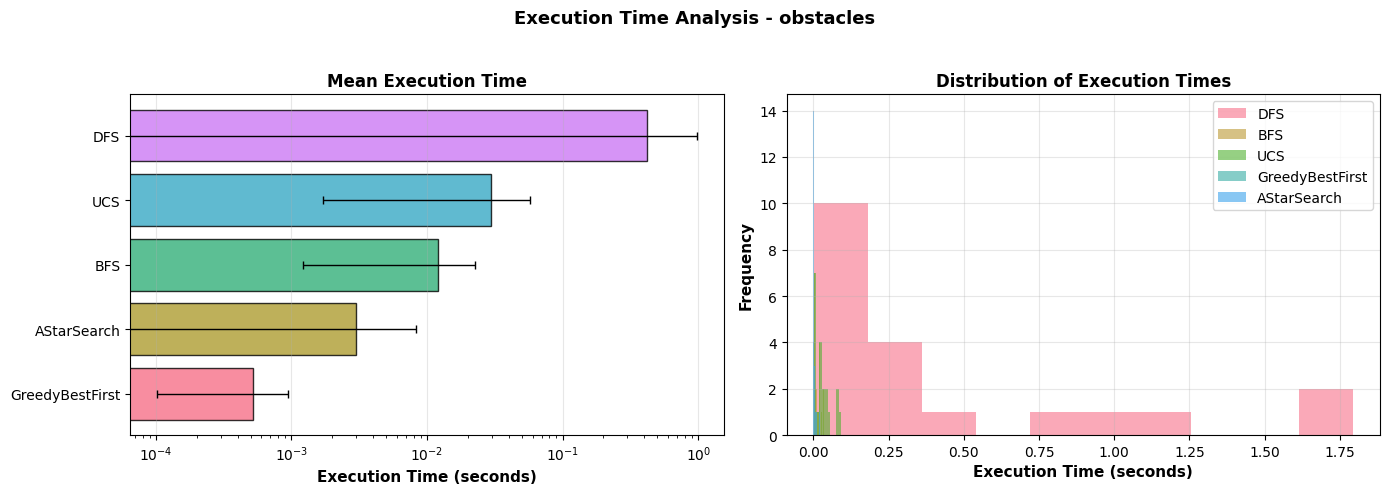

C:\Users\Thong\AppData\Local\Temp\ipykernel_22072\3205350605.py:81: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(plot_data, labels=df['algorithm'].unique(), vert=True, patch_artist=True)


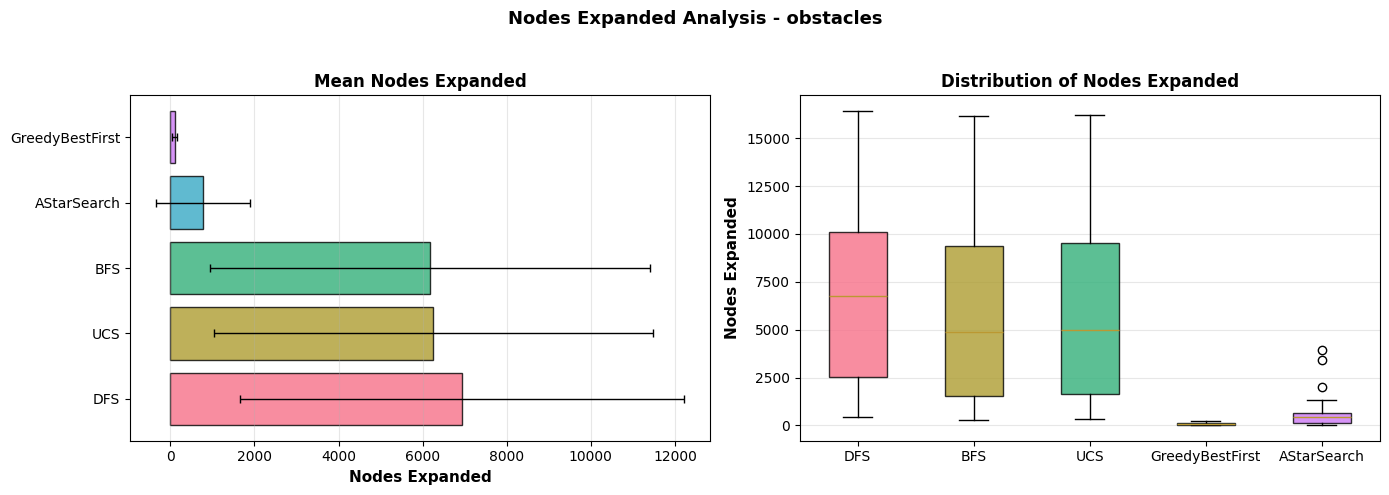


OBSTACLES Summary Statistics:
                best_fitness                           nodes_expanded  \
                        mean        std    min     max           mean   
algorithm                                                               
AStarSearch             78.4    47.1452   16.0   168.0         779.55   
BFS                     78.4    47.1452   16.0   168.0        6169.00   
DFS                   3598.5  2355.5515  354.0  7344.0        6937.20   
GreedyBestFirst         88.6    55.5844   18.0   186.0          99.90   
UCS                     78.4    47.1452   16.0   168.0        6254.10   

                           execution_time_seconds          
                       std                   mean     std  
algorithm                                                  
AStarSearch      1108.5646                 0.0030  0.0052  
BFS              5227.5242                 0.0120  0.0107  
DFS              5281.7136                 0.4160  0.5578  
GreedyBestFirst    65.65

In [63]:
case_name = 'obstacles'
if case_name in benchmark_results:
    df = benchmark_results[case_name]
    
    fig = analyze_path_length(df, case_name)
    plt.savefig(OUTPUT_DIR / f'{case_name}_pathlen_performance.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    fig = analyze_execution_time(df, case_name)
    plt.savefig(OUTPUT_DIR / f'{case_name}_execution_time.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    fig = analyze_nodes_expanded(df, case_name)
    plt.savefig(OUTPUT_DIR / f'{case_name}_nodes_expanded.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print_summary_stats(df, case_name)
else:
    print(f"Benchmark data not available for {case_name}")

### dense - Benchmark Results

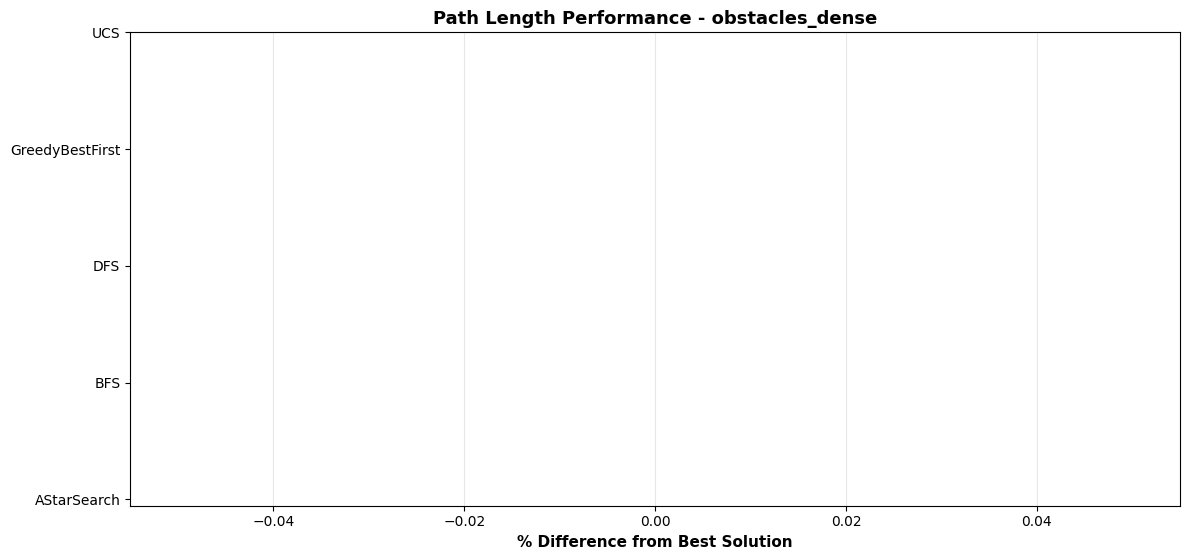

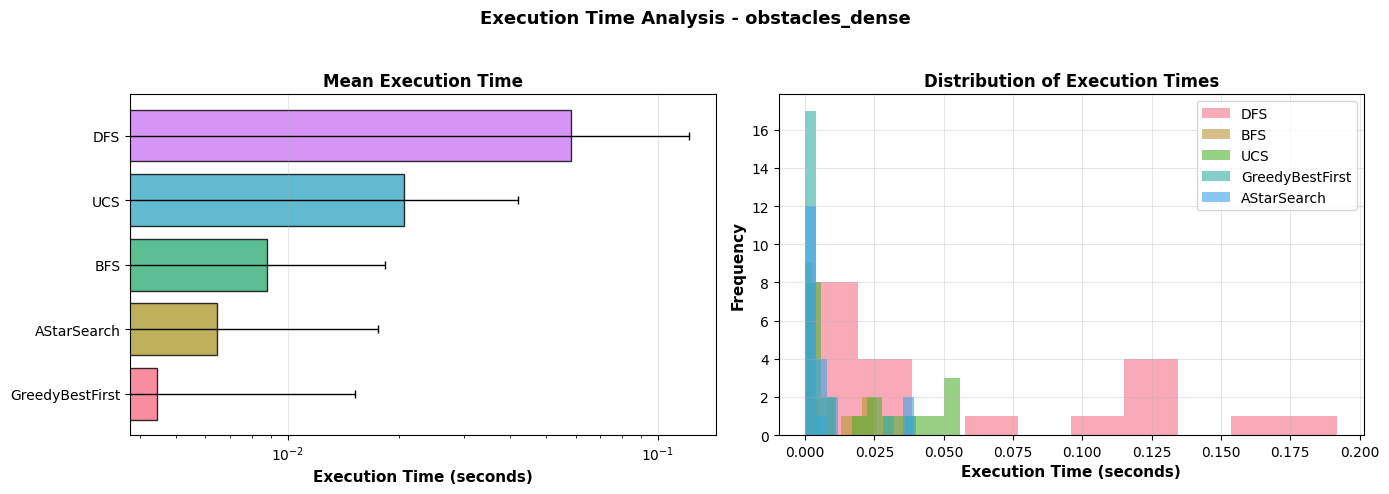

C:\Users\Thong\AppData\Local\Temp\ipykernel_22072\3205350605.py:81: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(plot_data, labels=df['algorithm'].unique(), vert=True, patch_artist=True)


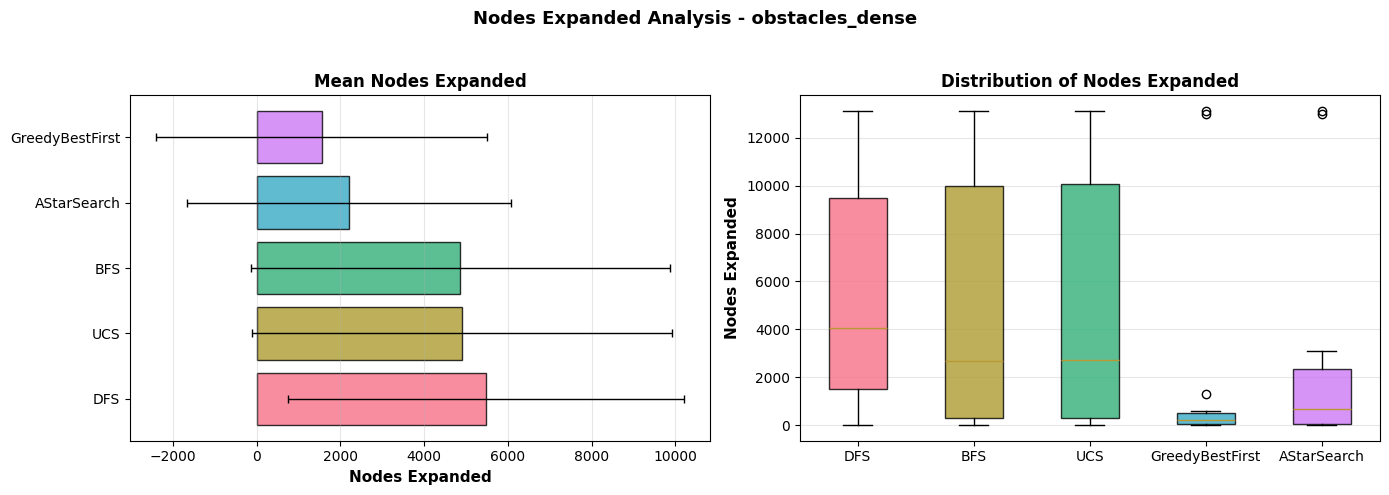


OBSTACLES_DENSE Summary Statistics:
                best_fitness                 nodes_expanded             \
                        mean std    min  max           mean        std   
algorithm                                                                
AStarSearch              inf NaN   21.0  inf        2205.90  3869.8488   
BFS                      inf NaN   21.0  inf        4863.10  4996.6694   
DFS                      inf NaN  164.0  inf        5473.45  4734.0457   
GreedyBestFirst          inf NaN   21.0  inf        1555.05  3949.4684   
UCS                      inf NaN   21.0  inf        4906.95  5017.6920   

                execution_time_seconds          
                                  mean     std  
algorithm                                       
AStarSearch                     0.0065  0.0111  
BFS                             0.0088  0.0095  
DFS                             0.0583  0.0631  
GreedyBestFirst                 0.0044  0.0108  
UCS                        

In [64]:
case_name = 'obstacles_dense'
if case_name in benchmark_results:
    df = benchmark_results[case_name]
    
    fig = analyze_path_length(df, case_name)
    plt.savefig(OUTPUT_DIR / f'{case_name}_pathlen_performance.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    fig = analyze_execution_time(df, case_name)
    plt.savefig(OUTPUT_DIR / f'{case_name}_execution_time.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    fig = analyze_nodes_expanded(df, case_name)
    plt.savefig(OUTPUT_DIR / f'{case_name}_nodes_expanded.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print_summary_stats(df, case_name)
else:
    print(f"Benchmark data not available for {case_name}")

### perfect_maze - Benchmark Results

C:\Users\Thong\AppData\Local\Temp\ipykernel_22072\3205350605.py:24: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


<Figure size 1000x600 with 0 Axes>

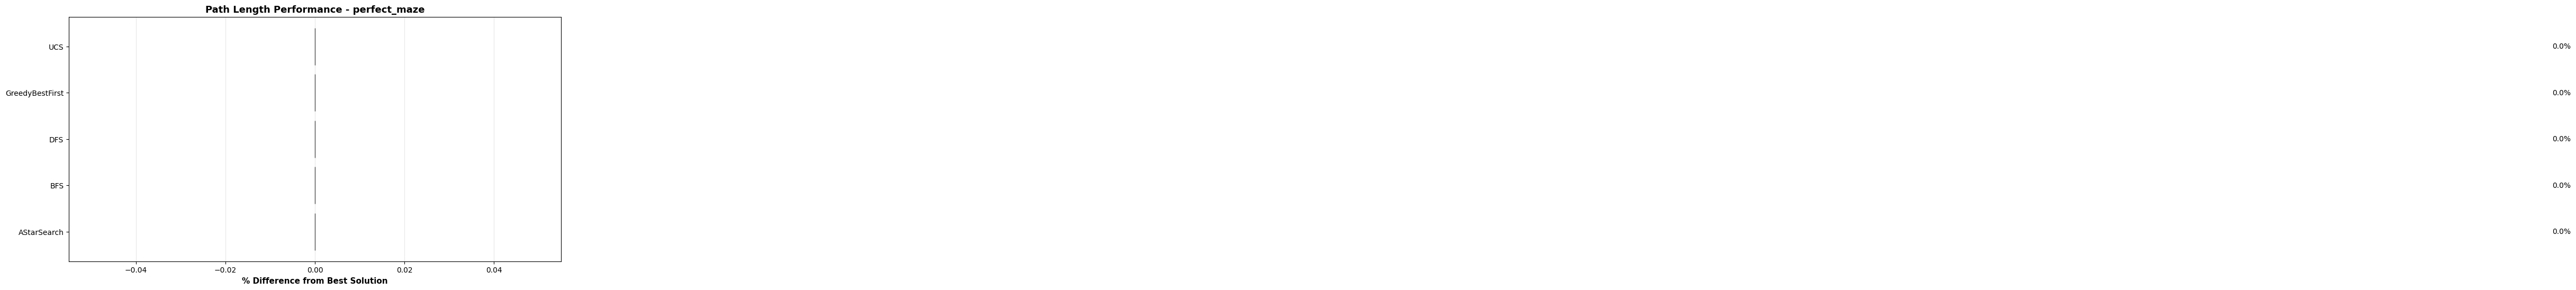

<Figure size 1000x600 with 0 Axes>

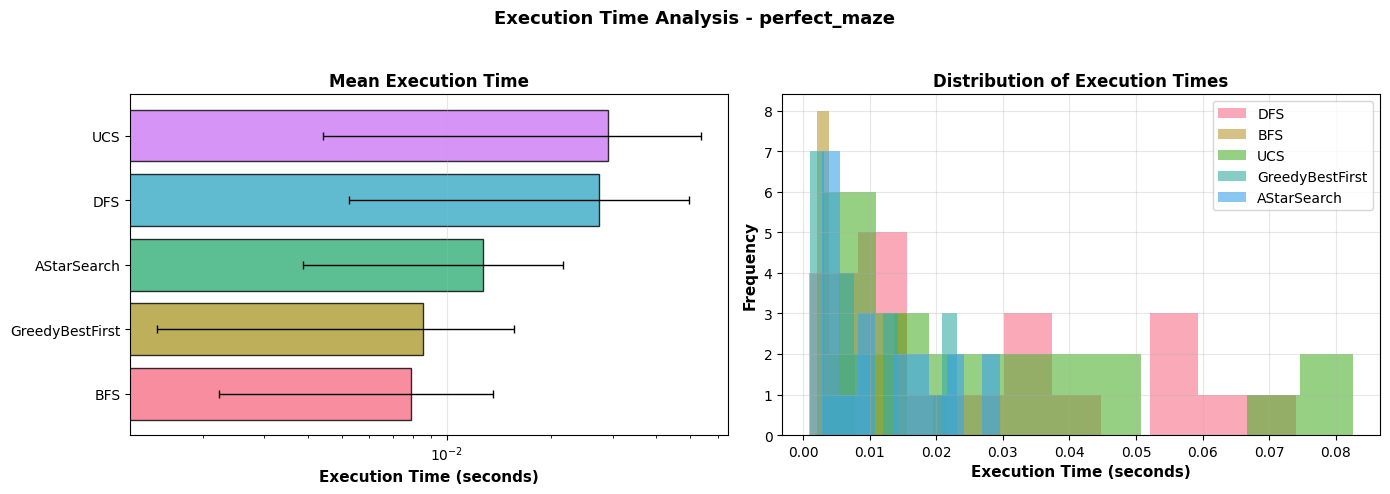

C:\Users\Thong\AppData\Local\Temp\ipykernel_22072\3205350605.py:81: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(plot_data, labels=df['algorithm'].unique(), vert=True, patch_artist=True)


<Figure size 1000x600 with 0 Axes>

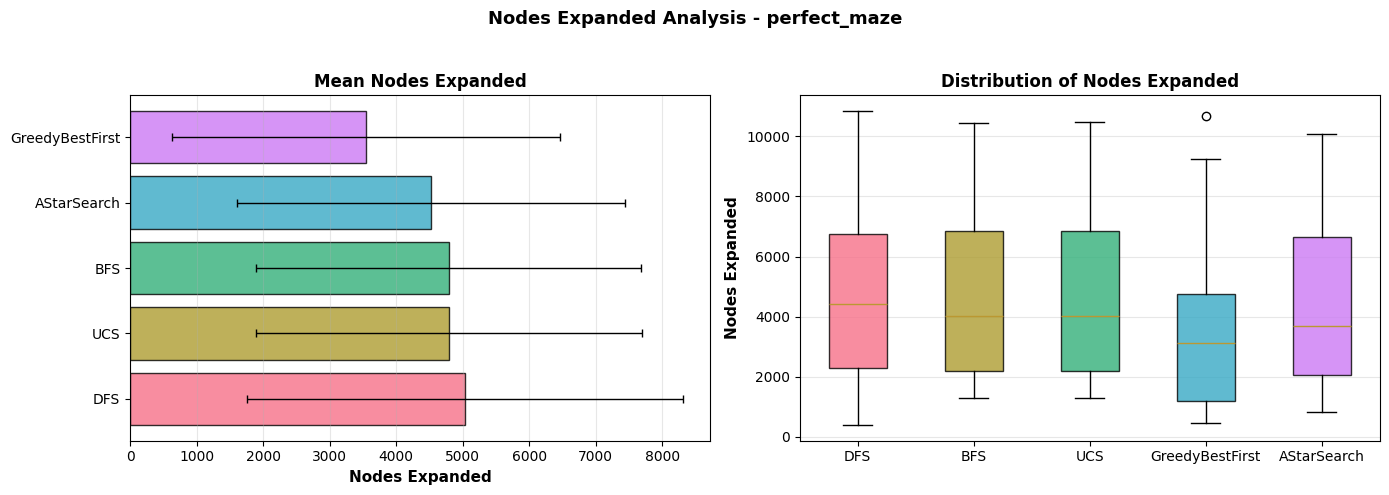


PERFECT_MAZE Summary Statistics:
                best_fitness                           nodes_expanded  \
                        mean        std    min     max           mean   
algorithm                                                               
AStarSearch          1458.35  1003.5823  377.0  4306.0        4527.40   
BFS                  1458.35  1003.5823  377.0  4306.0        4789.15   
DFS                  1458.35  1003.5823  377.0  4306.0        5032.10   
GreedyBestFirst      1458.35  1003.5823  377.0  4306.0        3542.15   
UCS                  1458.35  1003.5823  377.0  4306.0        4793.50   

                           execution_time_seconds          
                       std                   mean     std  
algorithm                                                  
AStarSearch      2914.0424                 0.0127  0.0088  
BFS              2897.7081                 0.0079  0.0057  
DFS              3278.2958                 0.0274  0.0222  
GreedyBestFirst  2917

In [65]:
case_name = 'perfect_maze'

if case_name in benchmark_results:
    df = benchmark_results[case_name]

    plt.figure(figsize=(10,6))
    fig = analyze_path_length(df, case_name)
    plt.savefig(OUTPUT_DIR / f'{case_name}_pathlen_performance.png', dpi=150, bbox_inches='tight')
    plt.show()

    plt.figure(figsize=(10,6))
    fig = analyze_execution_time(df, case_name)
    plt.savefig(OUTPUT_DIR / f'{case_name}_execution_time.png', dpi=150, bbox_inches='tight')
    plt.show()

    plt.figure(figsize=(10,6))
    fig = analyze_nodes_expanded(df, case_name)
    plt.savefig(OUTPUT_DIR / f'{case_name}_nodes_expanded.png', dpi=150, bbox_inches='tight')
    plt.show()

    print_summary_stats(df, case_name)

else:
    print(f"Benchmark data not available for {case_name}")

## Cross-Case Comparison

Compare algorithm performance across all test cases

Combined 5 test cases
Total results: 450


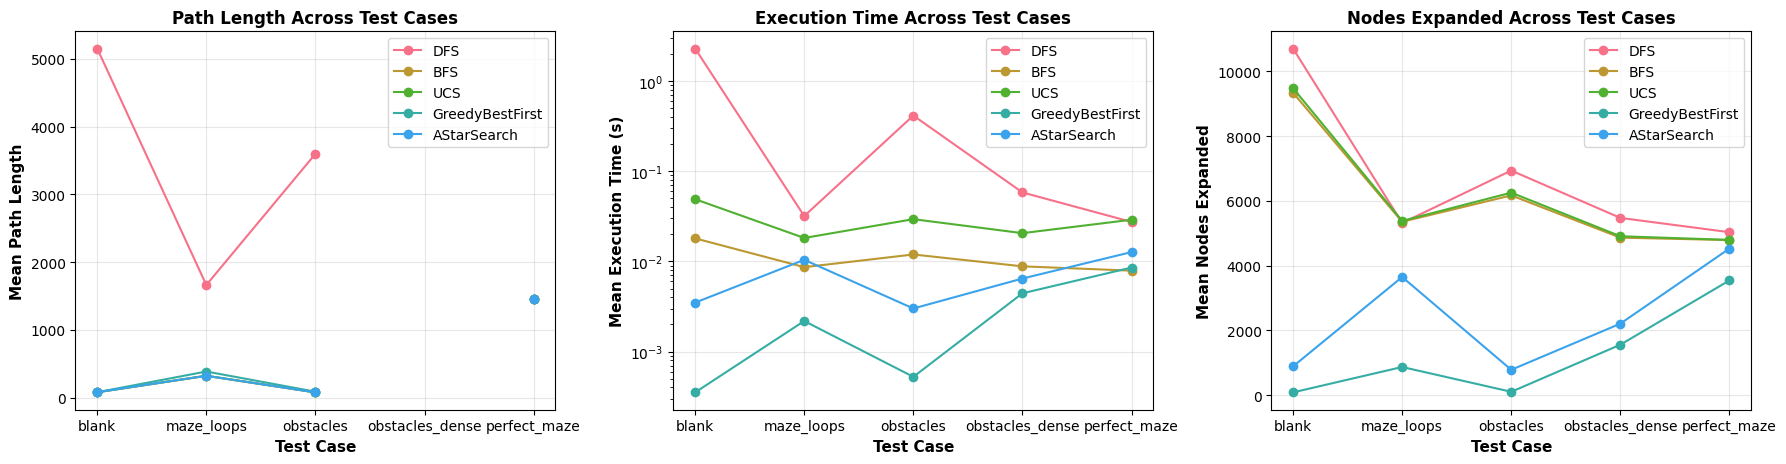

In [66]:
# Combine all benchmark results
if benchmark_results:
    all_data = []
    for case_name, df in benchmark_results.items():
        df['case'] = case_name
        all_data.append(df)
    
    combined_df = pd.concat(all_data, ignore_index=True)
    print(f"Combined {len(benchmark_results)} test cases")
    print(f"Total results: {len(combined_df)}")
    
    # Plot comparison across cases
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Path length by case
    case_path_stats = combined_df.groupby(['case', 'algorithm'])['best_fitness'].mean().reset_index()
    for algo in combined_df['algorithm'].unique():
        algo_data = case_path_stats[case_path_stats['algorithm'] == algo]
        axes[0].plot(algo_data['case'], algo_data['best_fitness'], marker='o', label=algo)
    axes[0].set_xlabel('Test Case', fontsize=11, fontweight='bold')
    axes[0].set_ylabel('Mean Path Length', fontsize=11, fontweight='bold')
    axes[0].set_title('Path Length Across Test Cases', fontsize=12, fontweight='bold')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    # Execution time by case
    case_time_stats = combined_df.groupby(['case', 'algorithm'])['execution_time_seconds'].mean().reset_index()
    for algo in combined_df['algorithm'].unique():
        algo_data = case_time_stats[case_time_stats['algorithm'] == algo]
        axes[1].plot(algo_data['case'], algo_data['execution_time_seconds'], marker='o', label=algo)
    axes[1].set_xlabel('Test Case', fontsize=11, fontweight='bold')
    axes[1].set_ylabel('Mean Execution Time (s)', fontsize=11, fontweight='bold')
    axes[1].set_title('Execution Time Across Test Cases', fontsize=12, fontweight='bold')
    axes[1].set_yscale('log')
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    
    # Nodes expanded by case
    case_nodes_stats = combined_df.groupby(['case', 'algorithm'])['nodes_expanded'].mean().reset_index()
    for algo in combined_df['algorithm'].unique():
        algo_data = case_nodes_stats[case_nodes_stats['algorithm'] == algo]
        axes[2].plot(algo_data['case'], algo_data['nodes_expanded'], marker='o', label=algo)
    axes[2].set_xlabel('Test Case', fontsize=11, fontweight='bold')
    axes[2].set_ylabel('Mean Nodes Expanded', fontsize=11, fontweight='bold')
    axes[2].set_title('Nodes Expanded Across Test Cases', fontsize=12, fontweight='bold')
    axes[2].legend()
    axes[2].grid(alpha=0.3)
    
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.savefig(OUTPUT_DIR / 'cross_case_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

## Summary

This analysis demonstrates:

### Stage 1: Visualization
- Grid structure and obstacle layout for each test case
- Path solutions from 5 different algorithms
- Solution quality and computational metrics

### Stage 2: Benchmark Analysis  
- Path length performance (% difference from best solution)
- Execution time comparison (mean and variance)
- Nodes expanded statistics (search efficiency)
- Cross-case comparison across all 5 test cases

### Key Insights
- **A* Search**: Typically finds optimal or near-optimal paths with efficient search
- **BFS**: Complete and optimal for unweighted graphs, moderate efficiency
- **Greedy Best-First**: Fast but may not find optimal solutions
- **UCS**: Optimal for weighted graphs, more expensive than BFS
- **DFS**: Generally inefficient for pathfinding, explores deeply before backtracking
